# Coarse Full Waveform Inversion

1. https://www.kaggle.com/competitions/waveform-inversion/code
2. https://www.kaggle.com/code/hanchenwang114/waveform-inversion-kaggle-competition-tutorial/notebook
3. https://arxiv.org/abs/2111.02926

## Imports

In [3]:
import os,sys; sys.path.append(os.getcwd().replace("fwi",""))
from util import get_torch_device_backend
from acoustic_forward_solver import acoustic_forward_solver, FWIPARAMETERS
from gauss_newton_solver import fwi_gn_solver
import chonknoris
import torch
import gpytorch
import lightning 
from matplotlib import pyplot,colors,cm
import os
import glob
import pandas as pd
import numpy as np
import timeit
import neuralop
import time 
import pyKoLesky.cholesky
import qmcpy as qp  # qmcpy==1.6.3rc0
import fastgps # fastgps==0.0.4.1b0
import warnings

## Torch Setup

In [4]:
torch.set_default_dtype(torch.float64)
torch.manual_seed(17)
DEVICE,TORCH_BACKEND = get_torch_device_backend(deviceidx=0)
print("DEVICE = %s"%str(DEVICE))
print("TORCH_BACKEND = %s"%str(TORCH_BACKEND.__name__))
EPS = torch.finfo(torch.get_default_dtype()).eps
EPS

DEVICE = cuda:0
TORCH_BACKEND = torch.cuda


2.220446049250313e-16

## Boilderplate

In [5]:
ROOT = "."
assert os.path.isfile(ROOT+"/fwi_cayley.ipynb")

In [6]:
pyplot.style.use('seaborn-v0_8-whitegrid')
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv(ROOT+"/../xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
COLORS[:3] = COLORS[:3][::-1]
LWTHICK = 3
LWTHIN = .05
HIGHLIGHTS = 4

## Load Dataset

In [7]:
pname = "RES5"
vtype = "Style_B"
tag = "SAVE"
outdir = './data/%s.%s.%s'%(pname,vtype,tag)
assert os.path.isdir(outdir)
p = FWIPARAMETERS[pname]
p

{'name': 'RES5',
 'nx': 5,
 'dx': 10,
 'nbc': 8,
 'nt': 72,
 'dt': 0.001,
 'freq': 35,
 'coord_sx': [0.7142857142857143, 12.5, 25.0, 37.857142857142854, 50.0],
 'coord_sz': [0.7142857142857143,
  0.7142857142857143,
  0.7142857142857143,
  0.7142857142857143,
  0.7142857142857143]}

In [8]:
data = torch.load(outdir+"/data_nk.pt",weights_only=True)
for _key,_val in data.items():
    print("data[%s].shape = %s"%(_key,str(tuple(_val.shape))))
data["l2rerrors"] = torch.linalg.norm(data["velocity"][:,None]-data["vs"],dim=(-2,-1))/torch.linalg.norm(data["velocity"][:,None],dim=(-2,-1)) # TODO: remove after patching in fwi_gn_solver
R,Ns,Nt,Nx = data["wavefield"].shape

data[vs].shape = (1000, 41, 5, 5)
data[rmses].shape = (1000, 41)
data[times].shape = (41,)
data[relaxations].shape = (1000, 41)
data[lrs].shape = (1000, 41)
data[updated].shape = (1000, 40)
data[Linvs].shape = (1000, 40, 25, 25)
data[l2rerrors].shape = (1000, 41)
data[v_true].shape = (1000, 5, 5)
data[w_true].shape = (1000, 5, 71, 5)
data[velocity].shape = (1000, 5, 5)
data[wavefield].shape = (1000, 5, 71, 5)
data[tidxs].shape = (750,)
data[vidxs].shape = (250,)


## Explore Dataset

In [9]:
print("L2 relative errors")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["l2rerrors"]).describe().T.iloc[::5])

L2 relative errors


,count,mean,std,min,25%,50%,75%,max
0,1000.0,8.129558e-02,1.177162e-02,5.571480e-02,7.331820e-02,7.979068e-02,8.767831e-02,1.508579e-01
5,1000.0,1.262362e-02,8.854724e-03,3.675120e-04,6.741417e-03,1.103666e-02,1.655242e-02,1.195979e-01
10,1000.0,3.021437e-04,8.520862e-04,1.555793e-09,1.399741e-05,5.817604e-05,2.127687e-04,1.002334e-02
15,1000.0,1.158101e-07,1.414229e-06,5.737073e-15,3.137889e-11,2.612261e-09,2.508459e-08,4.336042e-05
20,1000.0,2.305911e-11,2.373797e-10,2.882527e-15,1.085183e-14,1.819761e-14,5.534125e-14,5.105233e-09
25,1000.0,3.383246e-14,3.238076e-13,2.693574e-15,9.170242e-15,1.362564e-14,2.093408e-14,9.869260e-12
30,1000.0,1.686897e-14,1.259009e-14,2.693574e-15,8.985804e-15,1.333756e-14,2.019274e-14,1.112099e-13
35,1000.0,1.686020e-14,1.257788e-14,2.693574e-15,8.985804e-15,1.333756e-14,2.018706e-14,1.112099e-13
40,1000.0,1.686010e-14,1.257781e-14,2.693574e-15,8.985804e-15,1.333756e-14,2.018706e-14,1.112099e-13


In [10]:
print("Relaxations")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["relaxations"]).describe().T.iloc[::5])

Relaxations


,count,mean,std,min,25%,50%,75%,max
0,1000.0,1.000000e-05,1.694914e-21,1.000000e-05,1.000000e-05,1.000000e-05,1.000000e-05,1.000000e-05
5,1000.0,2.025313e-06,1.618933e-06,3.125000e-07,1.250000e-06,1.250000e-06,2.500000e-06,1.000000e-05
10,1000.0,1.121191e-07,9.690340e-08,9.765625e-09,7.812500e-08,7.812500e-08,1.562500e-07,1.250000e-06
15,1000.0,3.343750e-08,5.556871e-08,3.051758e-10,2.441406e-09,9.765625e-09,3.906250e-08,6.250000e-07
20,1000.0,1.786606e-08,4.347704e-08,1.525879e-10,2.441406e-09,4.882813e-09,9.765625e-09,6.250000e-07
25,1000.0,1.153320e-07,3.014094e-07,6.103516e-10,9.765625e-09,3.906250e-08,7.812500e-08,5.000000e-06
30,1000.0,3.457896e-06,9.668120e-06,2.441406e-09,1.562500e-07,6.250000e-07,2.500000e-06,1.600000e-04
35,1000.0,1.104272e-04,3.094440e-04,9.765625e-09,5.000000e-06,2.000000e-05,8.000000e-05,5.120000e-03
40,1000.0,3.533668e-03,9.902209e-03,3.125000e-07,1.600000e-04,6.400000e-04,2.560000e-03,1.638400e-01


In [11]:
print("Learning rates")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["lrs"]).describe().T.iloc[::5])

Learning rates


,count,mean,std,min,25%,50%,75%,max
0,1000.0,1.000000e+00,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000
5,1000.0,1.485000e+00,0.500025,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000
10,1000.0,1.433000e+00,0.495739,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000
15,1000.0,1.130750e+00,0.377875,6.250000e-02,1.000000e+00,1.000000e+00,1.000000e+00,2.000000
20,1000.0,5.657311e-01,0.525873,1.220703e-04,6.250000e-02,5.000000e-01,1.000000e+00,2.000000
25,1000.0,1.020776e-01,0.269560,1.192093e-07,4.882812e-04,3.906250e-03,3.125000e-02,2.000000
30,1000.0,4.555718e-03,0.035156,1.164153e-10,4.768372e-07,3.814697e-06,1.220703e-04,1.000000
35,1000.0,9.965711e-05,0.001439,1.136868e-13,4.656613e-10,3.725290e-09,1.192093e-07,0.031250
40,1000.0,1.278390e-07,0.000002,1.110223e-16,4.547474e-13,3.637979e-12,1.164153e-10,0.000061


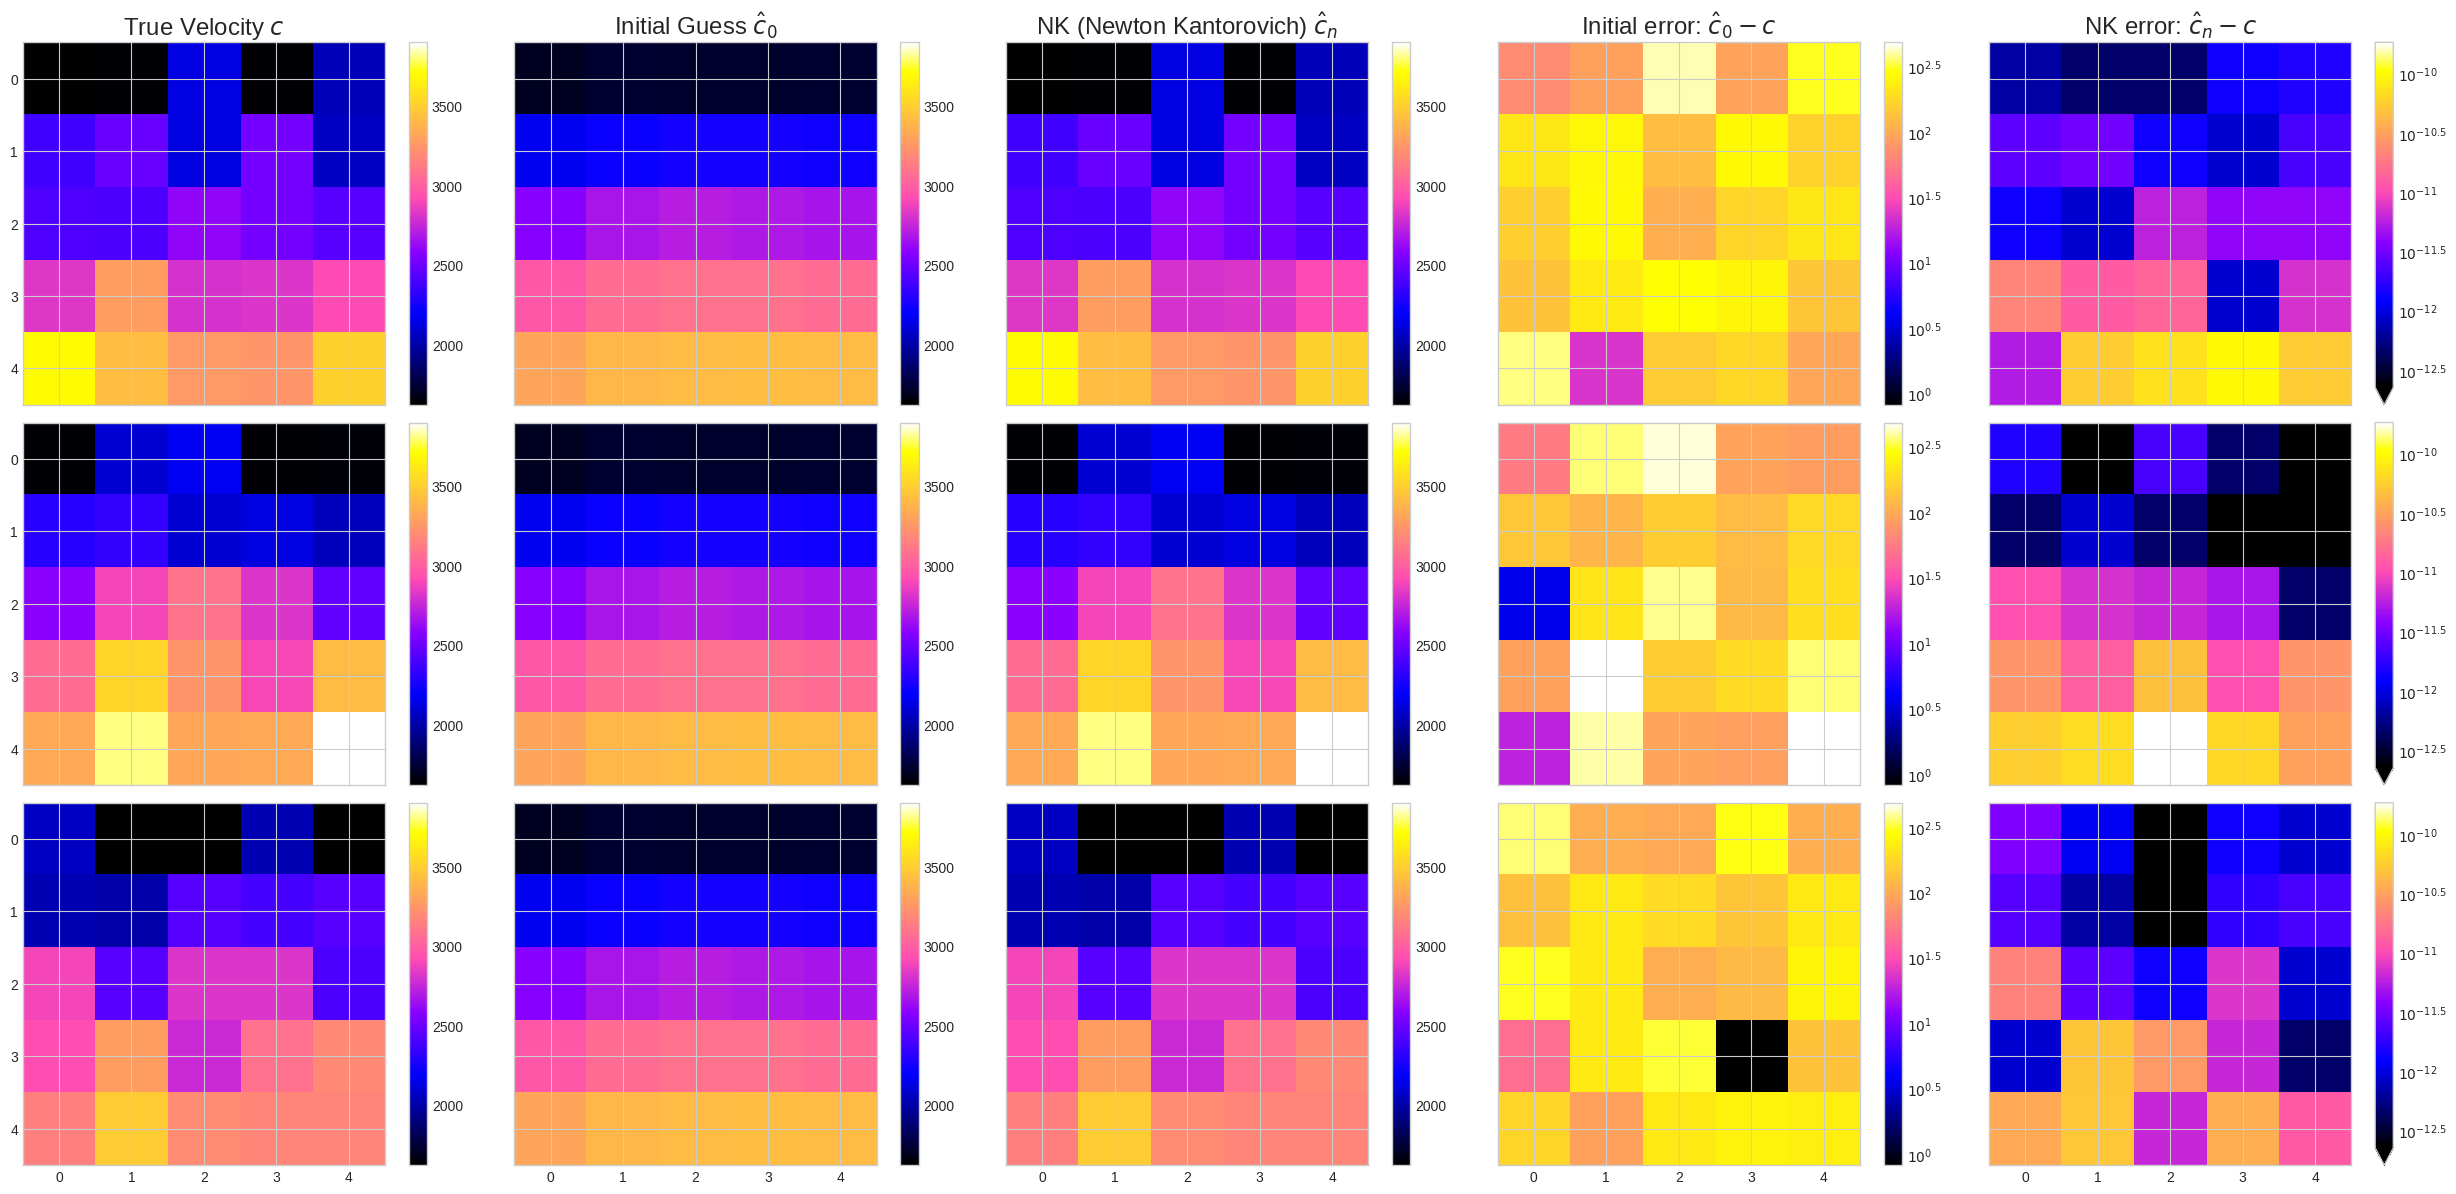

In [12]:
def plot_nk_velocities(v_true, v0, vfinal):
    initial_error_log10 = torch.log10(torch.abs(v_true-v0))
    final_error_log10 = torch.log10(torch.abs(v_true-vfinal))
    final_error_log10[final_error_log10==-torch.inf] = final_error_log10[final_error_log10.isfinite()].min()
    _initial_error_log10_amin = initial_error_log10.min()
    _initial_error_log10_amax = initial_error_log10.max()
    _final_error_log10_amin = final_error_log10.min()
    _final_error_log10_amax = final_error_log10.max()
    _cbmin = torch.min(v_true.min(),v0.min())
    _cbmax = torch.max(v_true.max(),v0.max())
    _plot_data = [
        (v_true,r"True Velocity $c$",_cbmin,_cbmax,False,None),
        (v0,r"Initial Guess $\hat{c}_0$",_cbmin,_cbmax,False,None),
        (vfinal,r"NK (Newton Kantorovich) $\hat{c}_n$",_cbmin,_cbmax,False,None),
        (initial_error_log10,r"Initial error: $\hat{c}_0-c$",_initial_error_log10_amin,_initial_error_log10_amax,True,None),
        (final_error_log10,r"NK error: $\hat{c}_n-c$",_final_error_log10_amin,_final_error_log10_amax,True,"min"),
        ]
    nrows = _plot_data[0][0].size(0)
    ncols = len(_plot_data)
    fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(5*ncols,4*nrows),sharex=True,sharey=True)
    ax = ax.reshape((nrows,ncols))
    for j,(_v,name,_vmin,_vmax,log10ed,extend) in enumerate(_plot_data):
        for i in range(nrows):
            cax = ax[i,j].imshow(_v[i].cpu(),cmap="gnuplot2",vmin=_vmin if _vmin is not None else None,vmax=_vmax if _vmax is not None else None)
            cbar = fig.colorbar(cax,extend=extend)
            if log10ed:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore",UserWarning)
                    cbar.ax.set_yticklabels([r"$10^{%s}$"%(int(_tick) if _tick%1==0 else _tick) for _tick in cbar.ax.get_yticks()]) 
        ax[0,j].set_title(name,fontsize="xx-large")
    fig.tight_layout()
    return fig,ax 
_R = 3
fig,ax = plot_nk_velocities(data["velocity"][:_R],data["vs"][:_R,0],data["vs"][:_R,-1])
fig.savefig(outdir+"/fwi_data.png",dpi=256)

/home/aleksei.sorokin/DeepNewtonOperator/chonknoris/plots.py:99: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,j].legend(frameon=False,fontsize="xx-large")


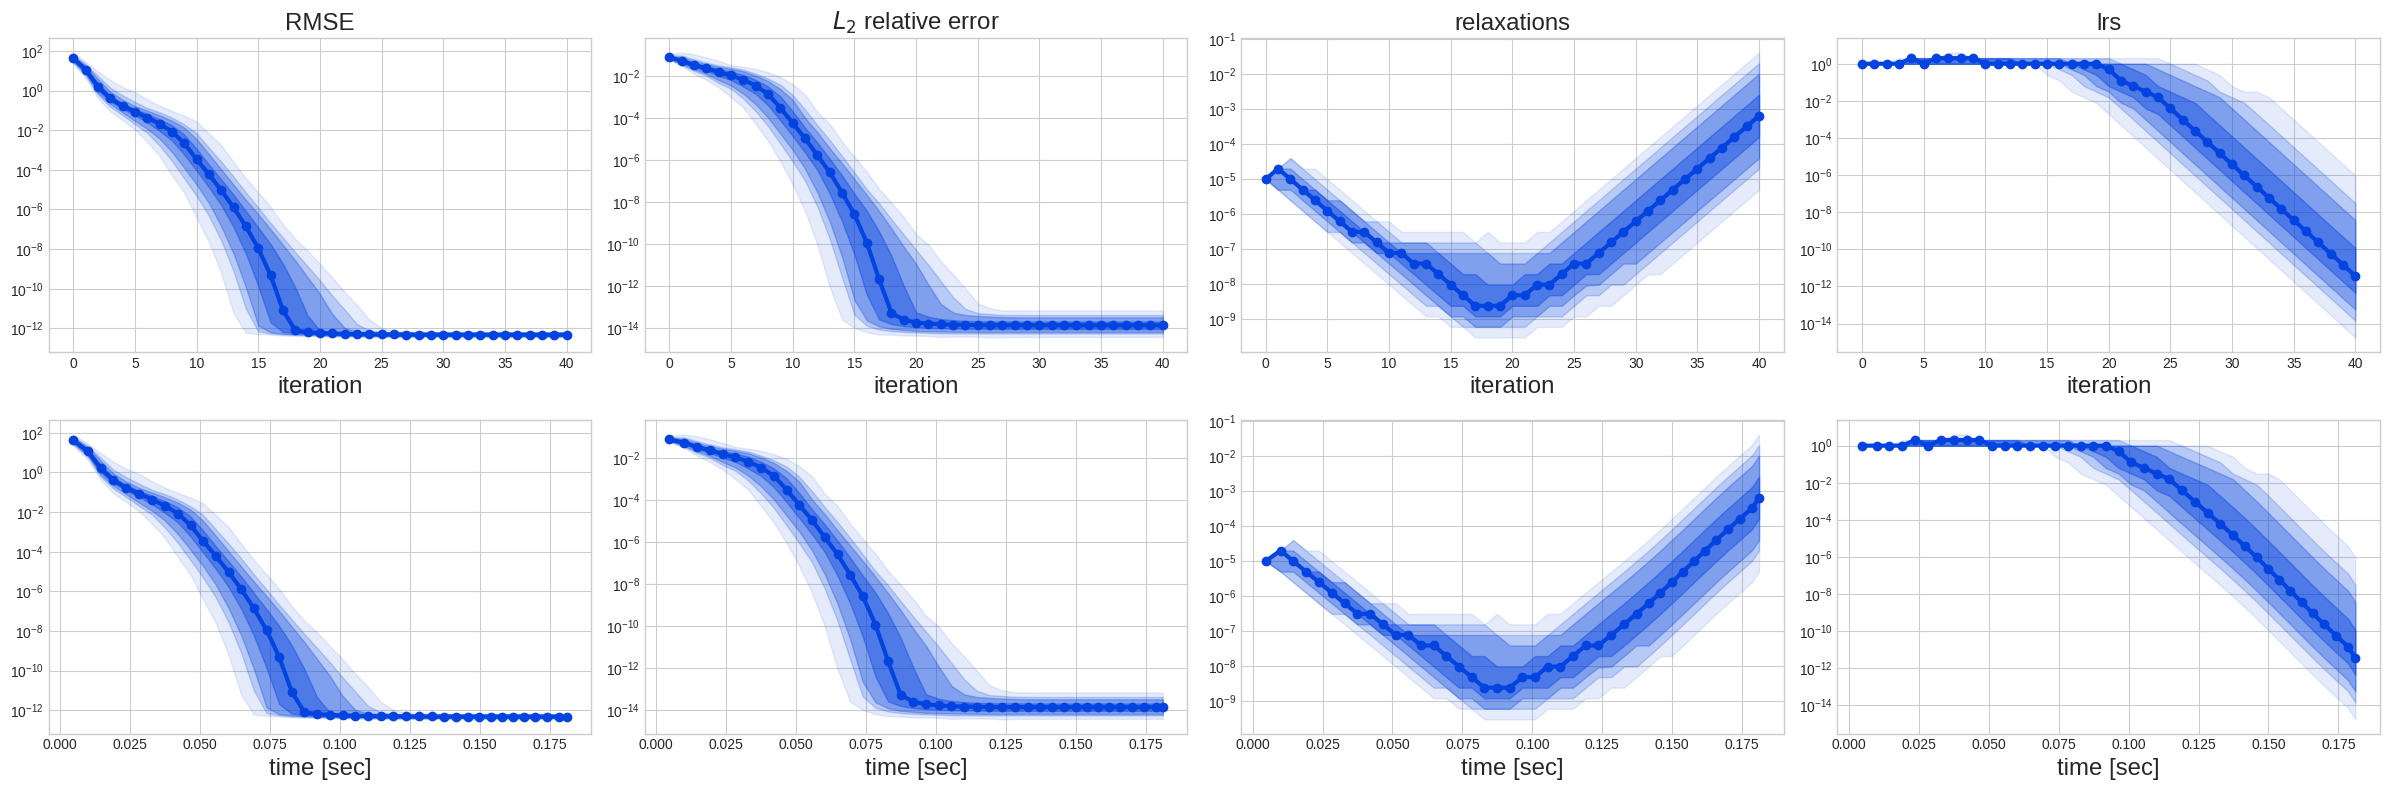

In [13]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [(None,data["rmses"],None)],
            [(None,data["l2rerrors"],None)],
            [(None,data["relaxations"],None)],
            [(None,data["lrs"],None)],

        ],
        [
            [(data["times"].cumsum(0),data["rmses"],None)],
            [(data["times"].cumsum(0),data["l2rerrors"],None)],
            [(data["times"].cumsum(0),data["relaxations"],None)],
            [(data["times"].cumsum(0),data["lrs"],None)],

        ],
    ],
    sharex = False,
    titles = [["RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None]],
    xlabels = [["iteration"],["time [sec]"]],
    xlogscale = False,
    colors = [COLORS[0]],
    ylogscale = True,
    fsx=4,fsy=6)
fig.tight_layout()
fig.savefig(outdir+"/fwi_coarse_nk_convergence.pdf",bbox_inches="tight")

## Gauss Newton Solves

In [13]:
vref = data["velocity"][:10].to(DEVICE)
w = data["wavefield"][:10].to(DEVICE)
v0 = data["vs"][:10,0].to(DEVICE)

### Standard

In [14]:
_,_data_gn = fwi_gn_solver(p,w,v0,num_newton_iter=40,relaxation=1e-5,lr=1,vref=vref,use_pca=False,store_Linvs=True)

    iter of 40     | time      | RMSE                                                             | L2 relative error                                   | relaxations                                         | lrs                                                 |
                   |           | 5%           median       mean         95%          finite %     | 5%           median       mean         95%          | 5%           median       mean         95%          | 5%           median       mean         95%          |
    -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0              | 7.20e+00  | 2.62e+01     3.95e+01     3.91e+01     5.36e+01     100.0        | 6.93e-02     7.53e-02     7.69e-02     8.80e-02     | 1.00e-05     1.00e-05     1.00e-05     1.00e-05     | 1.00e+

In [15]:
_L = torch.linalg.solve_triangular(torch.eye(_data_gn["Linvs"].size(-1),device=DEVICE),_data_gn["Linvs"].to(DEVICE),upper=False)
_Theta = torch.einsum("rikl,rijl->rikj",_L,_L)
_cond_nums = torch.linalg.cond(_Theta)

### PCA

velocity_train_mean.shape = (5, 5)
velocity_train_std.shape = (5, 5)
u_svd.shape = (750, 25)
s_svd.shape = (25,)
vh_svd.shape = (25, 25)
mat_svd_scaled.shape = (25, 25)
    iter of 40     | time      | RMSE                                                             | L2 relative error                                   | relaxations                                         | lrs                                                 |
                   |           | 5%           median       mean         95%          finite %     | 5%           median       mean         95%          | 5%           median       mean         95%          | 5%           median       mean         95%          |
    -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0              | 4.74e+00  | 2.62e+01    

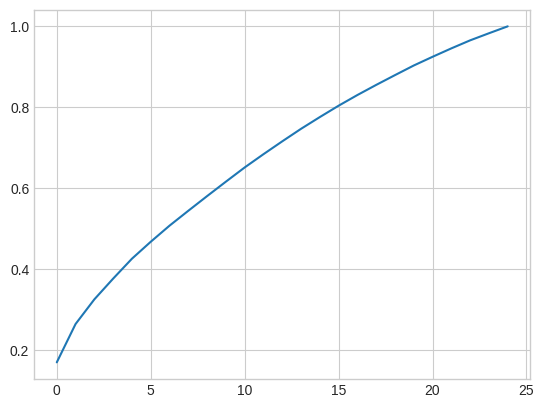

In [16]:
velocity_train_mean = data["velocity"][data["tidxs"]].mean(0)
print("velocity_train_mean.shape = %s"%str(tuple(velocity_train_mean.shape)))
velocity_train_std = data["velocity"][data["tidxs"]].std(0)
print("velocity_train_std.shape = %s"%str(tuple(velocity_train_std.shape)))
velocity_train_centered = (data["velocity"][data["tidxs"]]-velocity_train_mean)/velocity_train_std
velocity_train_centered_flat = velocity_train_centered.flatten(start_dim=1)
u_svd,s_svd,vh_svd = torch.linalg.svd(velocity_train_centered_flat,full_matrices=False)
print("u_svd.shape = %s"%str(tuple(u_svd.shape)))
print("s_svd.shape = %s"%str(tuple(s_svd.shape)))
print("vh_svd.shape = %s"%str(tuple(vh_svd.shape)))
assert torch.allclose((u_svd*s_svd)@vh_svd,velocity_train_centered_flat)
_mat_svd = (s_svd[:,None]*vh_svd).to(DEVICE)
mat_svd_scaled = _mat_svd*velocity_train_std.flatten(start_dim=-2).to(DEVICE)
print("mat_svd_scaled.shape = %s"%str(tuple(mat_svd_scaled.shape)))
explained_var_ratio = s_svd**2/(s_svd**2).sum()
explained_var_ratio_cumsum = explained_var_ratio.cumsum(dim=0)
pyplot.plot(explained_var_ratio_cumsum);
pca_data={
    "mat_svd_scaled": mat_svd_scaled.to(DEVICE),
    "velocity_train_mean": velocity_train_mean.to(DEVICE),
    "velocity_train_std": velocity_train_std.to(DEVICE),
    "vh_svd": vh_svd.to(DEVICE),
    "s_svd": s_svd.to(DEVICE)}
_,_data_gn_pca = fwi_gn_solver(p,w,v0,num_newton_iter=40,relaxation=1e2,lr=1,vref=vref,use_pca=True,pca_data=pca_data,store_Linvs=True)

In [17]:
_L = torch.linalg.solve_triangular(torch.eye(_data_gn_pca["Linvs"].size(-1),device=DEVICE),_data_gn_pca["Linvs"].to(DEVICE),upper=False)
_Theta = torch.einsum("rikl,rijl->rikj",_L,_L)
_cond_nums_pca = torch.linalg.cond(_Theta)

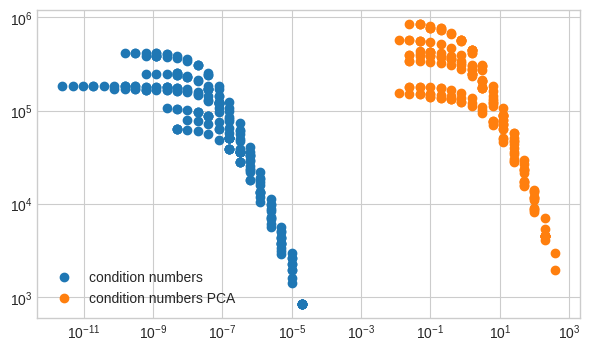

In [18]:
fig,ax = pyplot.subplots(figsize=(7,4))
ax.scatter(_data_gn["relaxations"][:,1:].flatten().cpu(),_cond_nums.flatten().cpu(),label="condition numbers")
ax.scatter(_data_gn_pca["relaxations"][:,1:].flatten().cpu(),_cond_nums_pca.flatten().cpu(),label="condition numbers PCA")
ax.set_xscale("log",base=10)
ax.set_yscale("log",base=10)
ax.legend(frameon=False);

## Initial Guess Model

### Load Data

In [14]:
outdir_igmodels = outdir+"/MODELS_IG"
if not os.path.isdir(outdir_igmodels): os.mkdir(outdir_igmodels)

In [15]:
inputs_raw_ig_t = data["wavefield"][data["tidxs"]].flatten(start_dim=1)
inputs_raw_ig_v = data["wavefield"][data["vidxs"]].flatten(start_dim=1)
outputs_raw_ig_t = data["velocity"][data["tidxs"]].flatten(start_dim=1)
outputs_raw_ig_v = data["velocity"][data["vidxs"]].flatten(start_dim=1)
inputs_raw_ig_t_mean = inputs_raw_ig_t.mean(0) 
inputs_raw_ig_t_std = inputs_raw_ig_t.std(0) 
inputs_raw_ig_t_std[inputs_raw_ig_t_std==0] = 1
outputs_raw_ig_t_mean = outputs_raw_ig_t.mean(0) 
outputs_raw_ig_t_std = outputs_raw_ig_t.std(0) 
#outputs_raw_ig_t_std[outputs_raw_ig_t_std==0] = 1
#outputs_raw_ig_t_mean[:] = 0
outputs_raw_ig_t_std[:] = 1
inputs_ig_t = (inputs_raw_ig_t-inputs_raw_ig_t_mean)/inputs_raw_ig_t_std
inputs_ig_v = (inputs_raw_ig_v-inputs_raw_ig_t_mean)/inputs_raw_ig_t_std
outputs_ig_t = (outputs_raw_ig_t-outputs_raw_ig_t_mean)/outputs_raw_ig_t_std
outputs_ig_v = (outputs_raw_ig_v-outputs_raw_ig_t_mean)/outputs_raw_ig_t_std
print("inputs_raw_ig_t.shape = %s"%str(tuple(inputs_raw_ig_t.shape)))
print("inputs_raw_ig_v.shape = %s"%str(tuple(inputs_raw_ig_v.shape)))
print("inputs_raw_ig_t_mean.shape = %s"%str(tuple(inputs_raw_ig_t_mean.shape)))
print("inputs_raw_ig_t_std.shape = %s"%str(tuple(inputs_raw_ig_t_std.shape)))
print("outputs_raw_ig_t.shape = %s"%str(tuple(outputs_raw_ig_t.shape)))
print("outputs_raw_ig_v.shape = %s"%str(tuple(outputs_raw_ig_v.shape)))
print("outputs_raw_ig_t_mean.shape = %s"%str(tuple(outputs_raw_ig_t_mean.shape)))
print("outputs_raw_ig_t_std.shape = %s"%str(tuple(outputs_raw_ig_t_std.shape)))
print("inputs_ig_t.shape = %s"%str(tuple(inputs_ig_t.shape)))
print("inputs_ig_v.shape = %s"%str(tuple(inputs_ig_v.shape)))
print("outputs_ig_t.shape = %s"%str(tuple(outputs_ig_t.shape)))
print("outputs_ig_v.shape = %s"%str(tuple(outputs_ig_v.shape)))

inputs_raw_ig_t.shape = (750, 1775)
inputs_raw_ig_v.shape = (250, 1775)
inputs_raw_ig_t_mean.shape = (1775,)
inputs_raw_ig_t_std.shape = (1775,)
outputs_raw_ig_t.shape = (750, 25)
outputs_raw_ig_v.shape = (250, 25)
outputs_raw_ig_t_mean.shape = (25,)
outputs_raw_ig_t_std.shape = (25,)
inputs_ig_t.shape = (750, 1775)
inputs_ig_v.shape = (250, 1775)
outputs_ig_t.shape = (750, 25)
outputs_ig_v.shape = (250, 25)


### MLP

In [17]:
import gc
gc.collect()
torch.cuda.empty_cache()

save_dir = outdir_igmodels
name = "MLP"
resume = True

ds_ig_t = chonknoris.DatasetClassic(inputs_ig_t,outputs_ig_t)
ds_ig_v = chonknoris.DatasetClassic(inputs_ig_v,outputs_ig_v)
print("len(ds_ig_t) = %d"%len(ds_ig_t))
print("len(ds_ig_v) = %d"%len(ds_ig_v))

dl_mlp_ig_t = torch.utils.data.DataLoader(ds_ig_t,batch_size=2**8,collate_fn=tuple,shuffle=True)
dl_mlp_ig_v = torch.utils.data.DataLoader(ds_ig_v,batch_size=len(ds_ig_v),collate_fn=tuple,shuffle=False)
print("len(dl_mlp_t) = %d"%len(dl_mlp_ig_t))
print("len(dl_mlp_v) = %d"%len(dl_mlp_ig_v))
print()

nn_ig = chonknoris.MLP(mlp_layer_nodes=[Ns*Nt*Nx]+5*[Nx*Nx],activation_function=torch.nn.Tanh())
#nn = chonknoris.MLP(mlp_layer_nodes=[1+Nx**2+Ns*Nt*Nx]+5*[1000]+[Nx**2*(1+Nx**2)//2],activation_function=torch.nn.Tanh())
lnn_ig = chonknoris.LightningNN(nn_ig,lr=1e-2,use_l2rerror_loss=True).to(DEVICE)
print(lnn_ig)

csv_logger = lightning.pytorch.loggers.CSVLogger(save_dir=save_dir,name=name,version='csv')
trainer = lightning.Trainer(
    max_epochs = 100,
    logger = [csv_logger],
    #accelerator = "cpu",
    #limit_train_batches=2**10,
    #log_every_n_steps = 1e10,
    enable_progress_bar = True,
    #num_sanity_val_steps = 0,
    #gradient_clip_val = 1.0,
    #gradient_clip_algorithm = "norm",
  )
trainer.fit(
    model = lnn_ig, 
    train_dataloaders = dl_mlp_ig_t,
    val_dataloaders = dl_mlp_ig_v,
    ckpt_path = sorted(glob.glob("./%s/%s/csv/checkpoints/*.ckpt"%(save_dir,name)),key=os.path.getmtime)[-1] if resume else None,
)


Trainer will use only 1 of 7 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=7)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


len(ds_ig_t) = 750
len(ds_ig_v) = 250
len(dl_mlp_t) = 3
len(dl_mlp_v) = 1

LightningNN(
  (nn): MLP(
    (nn_sequential): Sequential(
      (0): Linear(in_features=3500, out_features=49, bias=True)
      (1): Tanh()
      (2): Linear(in_features=49, out_features=49, bias=True)
      (3): Tanh()
      (4): Linear(in_features=49, out_features=49, bias=True)
      (5): Tanh()
      (6): Linear(in_features=49, out_features=49, bias=True)
      (7): Tanh()
      (8): Linear(in_features=49, out_features=49, bias=True)
    )
  )
)


IndexError: list index out of range

,train_avg_l2error,val_avg_l2error,train_avg_l2rerror,val_avg_l2rerror,train_loss,val_loss,train_rmse,val_rmse
0,2275.245613,2275.727848,0.999758,0.998867,52537.537016,52380.901685,229.205278,228.868743
12,2218.631986,2236.430520,0.975845,0.982340,50000.318240,50674.275620,223.605907,225.109475
24,2187.785764,2219.658236,0.962507,0.975319,48645.714099,49919.464984,220.553598,223.426643
36,2155.742608,2218.800287,0.949600,0.975082,47264.200067,49969.603641,217.401125,223.538819
48,2130.536267,2207.711733,0.938945,0.970985,46076.566196,49531.143841,214.650299,222.555934
60,2079.975036,2215.530427,0.918707,0.973633,43880.133607,49964.812181,209.475751,223.528102
72,2048.930005,2230.115489,0.906236,0.981451,42579.737866,50781.753299,206.343354,225.348071
84,2024.495152,2246.399988,0.895287,0.988931,41559.213572,51647.026662,203.859370,227.259822
96,1995.216701,2238.791228,0.883752,0.985112,40424.866658,51360.201265,201.059224,226.627892


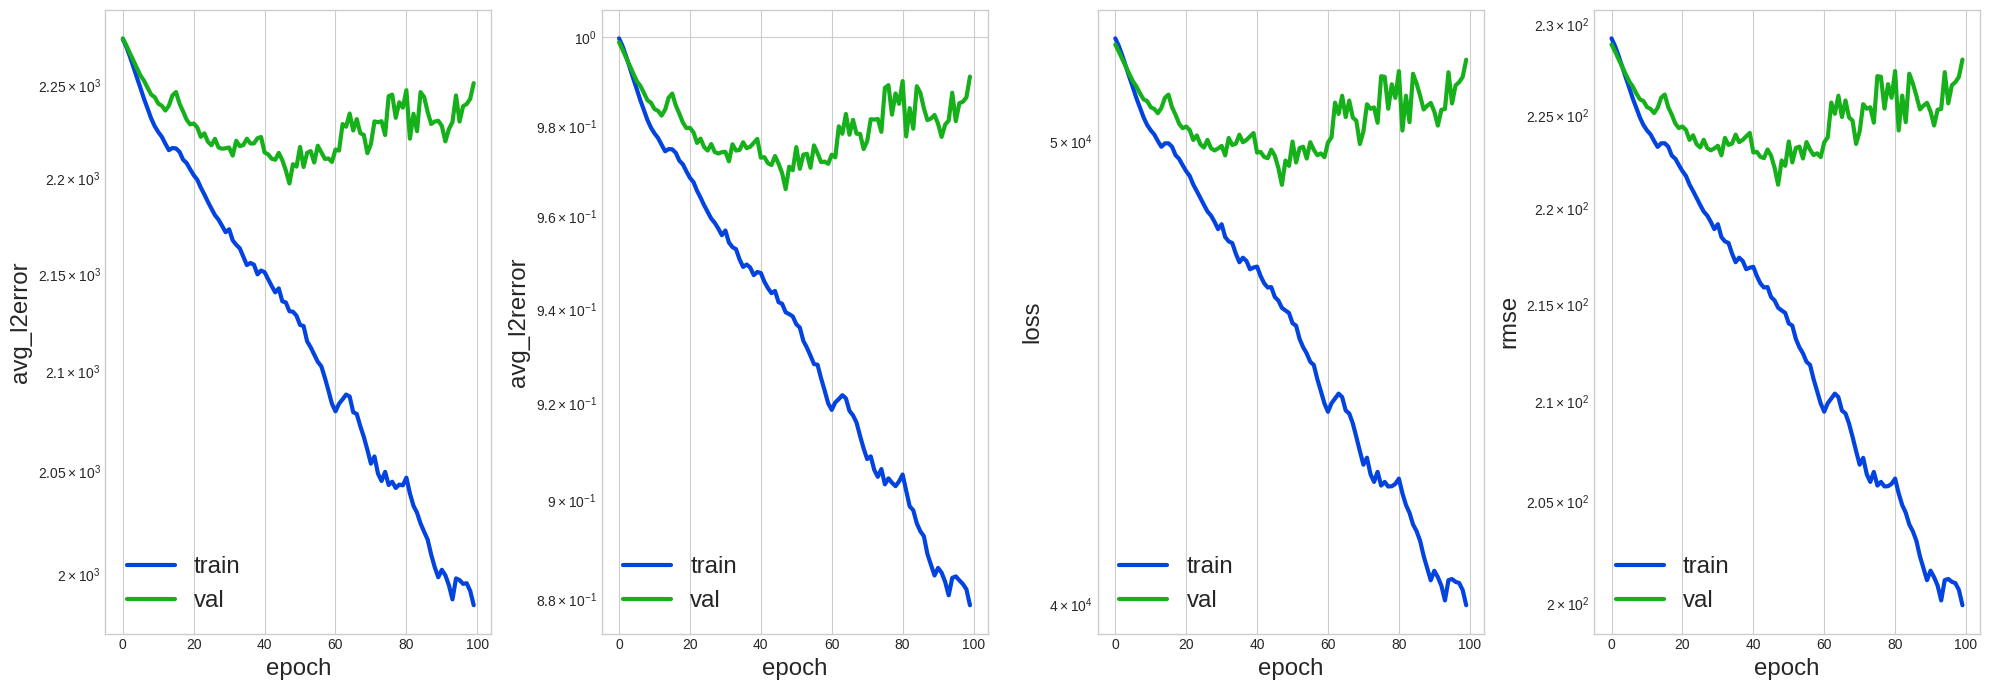

In [ ]:
metrics = chonknoris.parse_metrics("%s/%s/csv/metrics.csv"%(save_dir,name))
fig,ax = chonknoris.plot_metrics(metrics,linewidth=LWTHICK,color_train=COLORS[0],color_val=COLORS[1],s0=0)
fig.tight_layout()
metrics.iloc[::max(1,len(metrics)//8)]

In [ ]:
lnn_ig = lnn_ig.to(DEVICE) 
with torch.no_grad(), torch.inference_mode():
    outputs_v_hat_sgp_ig_raw_mlp = lnn_ig(inputs_ig_v.to(DEVICE))
outputs_v_hat_sgp_ig_mlp = outputs_v_hat_sgp_ig_raw_mlp*outputs_raw_ig_t_std.to(DEVICE)+outputs_raw_ig_t_mean.to(DEVICE)
print("l2 relative error: %.2e"%(torch.linalg.norm(outputs_v_hat_sgp_ig_mlp-outputs_raw_ig_v.to(DEVICE),dim=-1)/torch.linalg.norm(outputs_raw_ig_v.to(DEVICE),dim=-1)).mean())

l2 relative error: 8.04e-02


### GP

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

sgp_ig = fastgps.StandardGP(
    Ns*Nt*Nx,
    data={
        "x": inputs_ig_t.to(DEVICE),
        "y": outputs_ig_t.to(DEVICE).T},
    shape_batch=[Nx*Nx],
    device=DEVICE,
    compile_dist_func=True,
    #scale = 1, 
    shape_scale = [Nx*Nx,1],
    # shape_scale = [1],
    lengthscales=np.sqrt(Ns*Nt*Nx),
    # shape_lengthscales=[1],
    shape_lengthscales=[Ns*Nt*Nx],
    noise=1e-8,
    shape_noise=[Nx*Nx,1],
    # tfs_scale = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_lengthscales = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_noise = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_scale = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_lengthscales = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_noise = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_scale = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_lengthscales = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_noise = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # shape_noise=[1],
    requires_grad_noise=True,
    kernel_class="gaussian",
)
for pname,pval in sgp_ig.named_parameters():
    print("%s.shape = %s"%(pname,str(tuple(pval.shape))))
print()
fit_data_sgp_ig = sgp_ig.fit(
    loss_metric = "CV",
    #cv_weights = 1/torch.linalg.norm(outputs_ig_t.to(DEVICE),dim=1),
    iterations=20,
    verbose=1,
    store_hists=True,
    stop_crit_wait_iterations=np.inf,
    stop_crit_improvement_threshold=1e-1,
    #lr = 1e-3
    #optimizer = torch.optim.Rprop(sgp_ig.parameters(),lr=1e-1,etas=(1/1000,1001/1000),step_sizes=(0,5))
    )

raw_scale.shape = (25, 1)
raw_lengthscales.shape = (1775,)
raw_noise.shape = (25, 1)
raw_factor_task_kernel.shape = (1, 0)
raw_noise_task_kernel.shape = (1,)

     iter of 2.0e+01 | loss       | term1      | term2     
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 9.85e+07   | nan        | nan       
            1.00e+00 | 9.82e+07   | nan        | nan       
            2.00e+00 | 9.81e+07   | nan        | nan       
            3.00e+00 | 9.82e+07   | nan        | nan       
            4.00e+00 | 9.87e+07   | nan        | nan       
            5.00e+00 | 9.99e+07   | nan        | nan       
            6.00e+00 | 1.02e+08   | nan        | nan       
            7.00e+00 | 1.07e+08   | nan        | nan       
            8.00e+00 | 1.13e+08   | nan        | nan       
            9.00e+00 | 1.24e+08   | nan        | nan       
            1.00e+01 | 1.41e+08   | nan        | nan       
            1.10e+01 | 1.64e+08   | nan        | nan       
 

In [17]:
outputs_v_hat_sgp_ig_raw = sgp_ig.post_mean(inputs_ig_v.to(DEVICE)).T
outputs_v_hat_sgp_ig = outputs_v_hat_sgp_ig_raw*outputs_raw_ig_t_std.to(DEVICE)+outputs_raw_ig_t_mean.to(DEVICE)
print("l2 relative error: %.2e"%(torch.linalg.norm(outputs_v_hat_sgp_ig-outputs_raw_ig_v.to(DEVICE),dim=-1)/torch.linalg.norm(outputs_raw_ig_v.to(DEVICE),dim=-1)).mean())

l2 relative error: 2.36e-02


dict_keys(['iterations', 'loss_hist', 'scale_hist', 'lengthscales_hist', 'noise_hist', 'task_kernel_hist'])
fit_data_sgp_ig[loss_hist].shape = (21,)
fit_data_sgp_ig[scale_hist].shape = (21, 25, 1)
fit_data_sgp_ig[lengthscales_hist].shape = (21, 1775)
fit_data_sgp_ig[noise_hist].shape = (21, 25, 1)


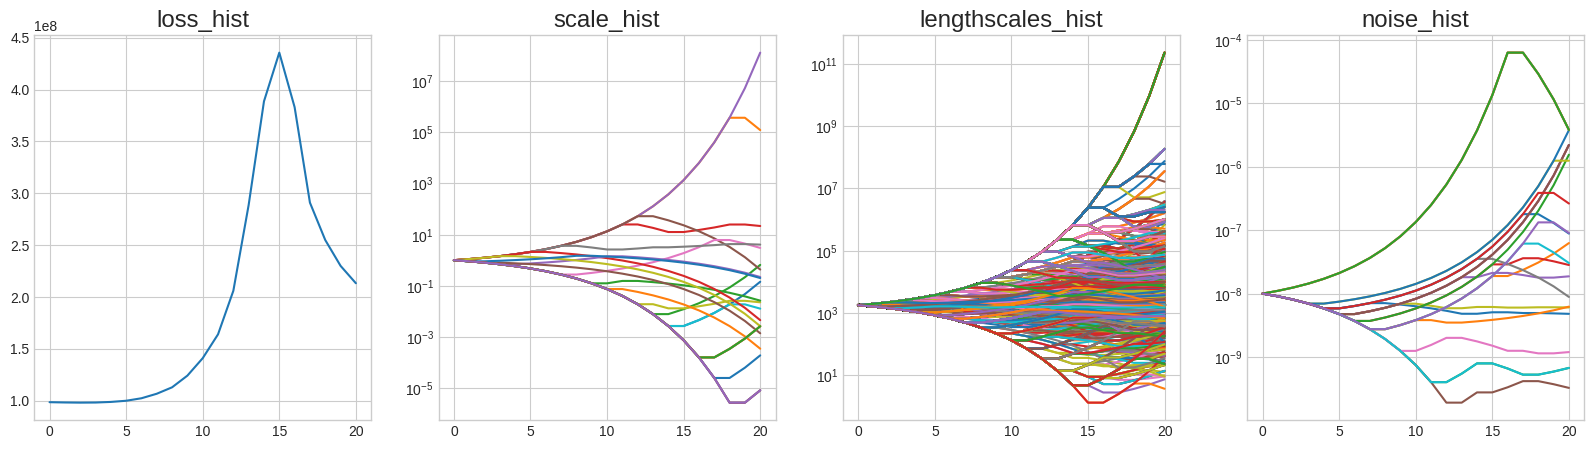

In [18]:
print(fit_data_sgp_ig.keys())
keys_to_plot_log10ed = [
    ('loss_hist',False),
    ('scale_hist',True),
    ('lengthscales_hist',True),
    ('noise_hist',True)]
ncols = len(keys_to_plot_log10ed)
fig,ax = pyplot.subplots(nrows=1,ncols=ncols,figsize=(5*ncols,5))
for i,(key,log10ed) in enumerate(keys_to_plot_log10ed):
    print("fit_data_sgp_ig[%s].shape = %s"%(key,str(tuple(fit_data_sgp_ig[key].shape))))
    if key in ["noise_hist","scale_hist"] and fit_data_sgp_ig[key].ndim==3:
        ax[i].plot(torch.arange(fit_data_sgp_ig[key].size(0)),fit_data_sgp_ig[key][:,:,0])
    else:
        ax[i].plot(torch.arange(fit_data_sgp_ig[key].size(0)),fit_data_sgp_ig[key])
    ax[i].set_title(key,fontsize="xx-large")
    if log10ed: ax[i].set_yscale('log',base=10)

## Dataloader

In [73]:
M = data["vs"].size(1) # total number of iterations
print("M = %d"%M)
Midxs = torch.arange(5)
#Midxs = torch.arange(10)
#Midxs = torch.arange(10,15)
# Midxs = torch.tensor([1,2,4,7,11,16,22,29,37])
#Midxs = torch.linspace(1,19,steps=10,dtype=int)
# Midxs = torch.linspace(1,39,steps=20,dtype=int)
#Midxs = torch.linspace(1,74,steps=25,dtype=int)
#Midxs = torch.linspace(1,29,steps=10,dtype=int)
#Midxs = torch.linspace(1,29,steps=5,dtype=int)
#Midxs = torch.linspace(1,9,steps=5,dtype=int)
print("Midxs = %s"%str(Midxs.numpy()))
print("len(Midxs) = %d"%len(Midxs))
assert (Midxs<(M-1)).all(), "Midxs must be less than M-1=%d"%(M-1)
outdir_chonknoris = outdir+"/MODELS_L"
if not os.path.isdir(outdir_chonknoris): os.mkdir(outdir_chonknoris)

M = 41
Midxs = [0 1 2 3 4]
len(Midxs) = 5


In [74]:
import gc
gc.collect()
torch.cuda.empty_cache()
_vs = data["vs"][:,Midxs]
vs_t = _vs[data["tidxs"]]
vs_v = _vs[data["vidxs"]]
_relaxations = data["relaxations"][:,Midxs+1]
relaxations_t = _relaxations[data["tidxs"]]
relaxations_v = _relaxations[data["vidxs"]]
_wavefield_full = torch.tile(data["wavefield"][:,None,:,:,:],(1,len(Midxs),1,1,1))
wavefield_full_t = _wavefield_full[data["tidxs"]]
wavefield_full_v = _wavefield_full[data["vidxs"]]
_eyeNx2 = torch.eye(Nx**2,device=DEVICE)
_updated = data["updated"][:,Midxs]
_Linvs = data["Linvs"][:,Midxs]
_L = torch.linalg.solve_triangular(_Linvs.to(DEVICE),_eyeNx2,upper=False).cpu()
_Theta = torch.einsum("...ij,...rj->...ir",_L.to(DEVICE),_L.to(DEVICE))
D = torch.nan*torch.zeros(_Theta[...,0].shape)
Q = torch.nan*torch.zeros(_Theta.shape)
C = torch.nan*torch.zeros(_Theta.shape)
_Du,_Qu = torch.linalg.eigh(_Theta[_updated.to(DEVICE)])
_detQu = torch.linalg.det(_Qu)
_detQun1flag = torch.isclose(_detQu,-torch.ones(1,device=DEVICE))
_flipper = torch.ones(Nx**2,device=DEVICE); _flipper[0] = -1
_Qu[_detQun1flag] = _Qu[_detQun1flag]*_flipper
assert torch.allclose(torch.linalg.det(_Qu),torch.ones(1,device=DEVICE))
assert torch.allclose(torch.einsum("...ij,...rj->...ir",_Qu*_Du[...,None,:],_Qu),_Theta[_updated.to(DEVICE)])
#_C = torch.linalg.solve(_eyeNx2+_Q,_eyeNx2-_Q,left=False) 
_Cu = torch.einsum("...ir,...rk->...ik",_eyeNx2-_Qu,torch.linalg.inv(_eyeNx2+_Qu))
assert torch.allclose(torch.einsum("...ir,...rk->...ik",_eyeNx2-_Qu,torch.linalg.inv(_eyeNx2+_Qu)),_Cu)
assert torch.allclose(_Cu,-_Cu.transpose(dim0=-2,dim1=-1),atol=1e-3)
D[_updated],Q[_updated],C[_updated] = _Du.cpu(),_Qu.cpu(),_Cu.cpu()
Gamma = D-_relaxations[...,None]
assert (Gamma[_updated]>0).all()
# print(torch.einsum("...ir,...rk->...ik",_eyeNx2-_C,torch.linalg.inv(_eyeNx2+_C))-_Q)
# assert torch.allclose(torch.einsum("...ir,...rk->...ik",_eyeNx2-_C,torch.linalg.inv(_eyeNx2+_C)),_Q)
# print(_Q.shape)
# print(_eyeNx2.shape)
# common_relaxation = 1e-5
# Theta = (torch.einsum("rijk,rilk->rijl",_L,_L)-_relaxations[:,:,None,None].to(DEVICE))*_eyeNx2+common_relaxation*_eyeNx2
# _L = torch.linalg.cholesky(Theta).cpu()
# _Linvs = data["Linvs"][:,Midxs]
# Linvs_t = _Linvs[data["tidxs"]]
# Linvs_v = _Linvs[data["vidxs"]]
# L_t = torch.linalg.solve_triangular(Linvs_t.to(DEVICE),_eyeNx2,upper=False).to("cpu")-relaxations_t[...,None,None]
# L_v = torch.linalg.solve_triangular(Linvs_v.to(DEVICE),_eyeNx2,upper=False).to("cpu")-relaxations_v[...,None,None]
# Theta_t = Theta[data["tidxs"]]
# Theta_v = Theta[data["vidxs"]]
#_L = data["Linvs"][:,Midxs]
L_t = _L[data["tidxs"]]
L_v = _L[data["vidxs"]]
Gamma_t = Gamma[data["tidxs"]]
Gamma_v = Gamma[data["vidxs"]]
C_t = C[data["tidxs"]]
C_v = C[data["vidxs"]]
#JtF_t = torch.einsum("rijk,rik->rij",L_t,torch.einsum("rikj,rik->rij",L_t,(vs_t[:,1:]-vs_t[:,:-1]).flatten(start_dim=-2)))
#JtF_v = torch.einsum("rijk,rik->rij",L_v,torch.einsum("rikj,rik->rij",L_v,(vs_v[:,1:]-vs_v[:,:-1]).flatten(start_dim=-2)))
updated_t = _updated[data["tidxs"]].cpu()
updated_v = _updated[data["vidxs"]].cpu()

In [75]:
print("vs_t.shape = %s"%str(tuple(vs_t.shape)))
print("vs_v.shape = %s"%str(tuple(vs_v.shape)))
print("relaxations_t.shape = %s"%str(tuple(relaxations_t.shape)))
print("relaxations_v.shape = %s"%str(tuple(relaxations_v.shape)))
print("wavefield_full_t.shape = %s"%str(tuple(wavefield_full_t.shape)))
print("wavefield_full_v.shape = %s"%str(tuple(wavefield_full_v.shape)))
# print("Linvs_t.shape = %s"%str(tuple(Linvs_t.shape)))
# print("Linvs_v.shape = %s"%str(tuple(Linvs_v.shape)))
# print("Theta_t.shape = %s"%str(tuple(Theta_t.shape)))
# print("Theta_v.shape = %s"%str(tuple(Theta_v.shape)))
# print("L_t.shape = %s"%str(tuple(L_t.shape)))
# print("L_v.shape = %s"%str(tuple(L_v.shape)))
# print("JtF_t.shape = %s"%str(tuple(JtF_t.shape)))
# print("JtF_v.shape = %s"%str(tuple(JtF_v.shape)))
print("Gamma_t.shape = %s"%str(tuple(Gamma_t.shape)))
print("Gamma_v.shape = %s"%str(tuple(Gamma_v.shape)))
print("C_t.shape = %s"%str(tuple(C_t.shape)))
print("C_v.shape = %s"%str(tuple(C_v.shape)))
print("updated_t.shape = %s"%str(tuple(updated_t.shape)))
print("updated_v.shape = %s"%str(tuple(updated_v.shape)))

vs_t.shape = (750, 5, 5, 5)
vs_v.shape = (250, 5, 5, 5)
relaxations_t.shape = (750, 5)
relaxations_v.shape = (250, 5)
wavefield_full_t.shape = (750, 5, 5, 71, 5)
wavefield_full_v.shape = (250, 5, 5, 71, 5)
Gamma_t.shape = (750, 5, 25)
Gamma_v.shape = (250, 5, 25)
C_t.shape = (750, 5, 25, 25)
C_v.shape = (250, 5, 25, 25)
updated_t.shape = (750, 5)
updated_v.shape = (250, 5)


In [102]:
lti0,lti1 = torch.tril_indices(Nx**2,Nx**2)
lt1i0,lt1i1 = torch.tril_indices(Nx**2,Nx**2,-1)
inputs_raw_t = torch.cat([vs_t[updated_t].flatten(start_dim=1),wavefield_full_t[updated_t].flatten(start_dim=1)],dim=-1)
inputs_raw_v = torch.cat([vs_v[updated_v].flatten(start_dim=1),wavefield_full_v[updated_v].flatten(start_dim=1)],dim=-1)
# inputs_raw_t = torch.cat([torch.log(relaxations_t[updated_t][:,None]),vs_t[updated_t].flatten(start_dim=1),wavefield_full_t[updated_t].flatten(start_dim=1)],dim=-1)
# inputs_raw_v = torch.cat([torch.log(relaxations_v[updated_v][:,None]),vs_v[updated_v].flatten(start_dim=1),wavefield_full_v[updated_v].flatten(start_dim=1)],dim=-1)
# inputs_raw_t = torch.cat([vs_t[:,:-1][updated_t].flatten(start_dim=1),wavefield_full_t[updated_t].flatten(start_dim=1)],dim=-1)
# inputs_raw_v = torch.cat([vs_v[:,:-1][updated_v].flatten(start_dim=1),wavefield_full_v[updated_v].flatten(start_dim=1)],dim=-1)
print("inputs_raw_t.shape = %s"%str(tuple(inputs_raw_t.shape)))
print("inputs_raw_v.shape = %s"%str(tuple(inputs_raw_v.shape)))
inputs_raw_t_mean = inputs_raw_t.mean(0).to(DEVICE)
inputs_raw_t_std = inputs_raw_t.std(0).to(DEVICE)
inputs_raw_t_std[inputs_raw_t_std==0] = 1
inputs_t = (inputs_raw_t-inputs_raw_t_mean.to("cpu"))/inputs_raw_t_std.to("cpu")
inputs_v = (inputs_raw_v-inputs_raw_t_mean.to("cpu"))/inputs_raw_t_std.to("cpu")
print("inputs_t.shape = %s"%str(tuple(inputs_raw_t.shape)))
print("inputs_v.shape = %s"%str(tuple(inputs_raw_v.shape)))
# outputs_t = (vs_t[:,1:]-vs_t[:,:-1])[updated_t].flatten(start_dim=1)
# outputs_v = (vs_v[:,1:]-vs_v[:,:-1])[updated_v].flatten(start_dim=1)
# outputs_t = Linvs_t[updated_t][:,lti0,lti1]
# outputs_v = Linvs_v[updated_v][:,lti0,lti1]
# outputs_raw_t = L_t[updated_t]
# outputs_raw_v = L_v[updated_v]
# _Nxr2 = torch.arange(Nx*Nx)
# outputs_raw_t[:,_Nxr2,_Nxr2] = outputs_raw_t[:,_Nxr2,_Nxr2]
# outputs_raw_v[:,_Nxr2,_Nxr2] = outputs_raw_v[:,_Nxr2,_Nxr2]
# outputs_raw_t = outputs_raw_t[:,lti0,lti1]
# outputs_raw_v = outputs_raw_v[:,lti0,lti1]
outputs_raw_t = torch.cat([torch.log10(Gamma_t[updated_t]),C_t[updated_t][:,lt1i0,lt1i1]],dim=-1)
outputs_raw_v = torch.cat([torch.log10(Gamma_v[updated_v]),C_v[updated_v][:,lt1i0,lt1i1]],dim=-1)
outputs_raw_t_mean = outputs_raw_t.mean(0).to(DEVICE)
outputs_raw_t_std = outputs_raw_t.std(0).to(DEVICE)
outputs_raw_t_mean[:] = 0
outputs_raw_t_std[:] = 1
outputs_raw_t_std[outputs_raw_t_std==0] = 1
outputs_t = (outputs_raw_t-outputs_raw_t_mean.to("cpu"))/outputs_raw_t_std.to("cpu")
outputs_v = (outputs_raw_v-outputs_raw_t_mean.to("cpu"))/outputs_raw_t_std.to("cpu")
# outputs_t[:,_Nxr2,_Nxr2] = torch.log(outputs_t[:,_Nxr2,_Nxr2])
# outputs_v[:,_Nxr2,_Nxr2] = torch.log(outputs_v[:,_Nxr2,_Nxr2])
# outputs_t = outputs_t[:,lti0,lti1]
# outputs_v = outputs_v[:,lti0,lti1]
ds_t = chonknoris.DatasetClassic(inputs_t,outputs_t)
ds_v = chonknoris.DatasetClassic(inputs_v,outputs_v)
print("outputs_t.shape = %s"%str(tuple(outputs_t.shape)))
print("outputs_v.shape = %s"%str(tuple(outputs_v.shape)))
print("len(ds_t) = %d"%len(ds_t))
print("len(ds_v) = %d"%len(ds_v))

inputs_raw_t.shape = (3750, 1800)
inputs_raw_v.shape = (1250, 1800)
inputs_t.shape = (3750, 1800)
inputs_v.shape = (1250, 1800)
outputs_t.shape = (3750, 325)
outputs_v.shape = (1250, 325)
len(ds_t) = 3750
len(ds_v) = 1250


torch.Size([3750, 300])


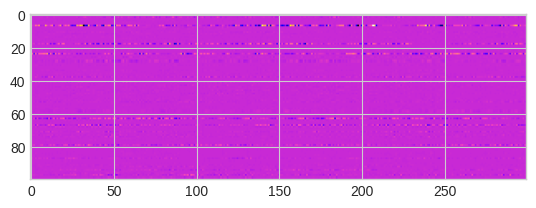

In [115]:
_Ctu = C_t[updated_t][:,lt1i0,lt1i1]
print(_Ctu.shape)
pyplot.imshow(_Ctu[:100,:],cmap="gnuplot2")
# pyplot.imshow(_Ctu[440:445,:10],cmap="gnuplot2")

In [104]:
Gamma_t[updated_t][:2]

tensor([[1.4181e-07, 6.2242e-07, 3.2189e-06, 4.1770e-06, 5.2701e-06, 1.1666e-05,
         2.1703e-05, 2.6996e-05, 6.4499e-05, 7.8113e-05, 1.3313e-04, 1.5006e-04,
         2.1038e-04, 2.6282e-04, 4.8384e-04, 6.2680e-04, 1.7926e-03, 2.1171e-03,
         2.4137e-03, 2.6933e-03, 4.1944e-03, 6.1071e-03, 9.4625e-03, 1.2396e-02,
         1.7292e-02],
        [1.2290e-07, 5.4019e-07, 3.1794e-06, 3.7770e-06, 5.4099e-06, 1.0261e-05,
         2.0307e-05, 2.4958e-05, 6.6835e-05, 1.0274e-04, 1.6967e-04, 1.7478e-04,
         2.2004e-04, 2.9876e-04, 1.0347e-03, 1.1449e-03, 2.4815e-03, 3.0497e-03,
         3.3887e-03, 4.6813e-03, 6.1529e-03, 6.8760e-03, 1.3238e-02, 1.6715e-02,
         2.3692e-02]])

In [106]:
outputs_t[:3,:5]

tensor([[-6.8483, -6.2059, -5.4923, -5.3791, -5.2782],
        [-6.9105, -6.2675, -5.4977, -5.4229, -5.2668],
        [-6.9530, -6.2867, -5.4733, -5.4496, -5.3185]])

## MLP

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

save_dir = outdir_chonknoris
name = "MLP"
resume = False

dl_mlp_t = torch.utils.data.DataLoader(ds_t,batch_size=2**8,collate_fn=tuple,shuffle=True)
dl_mlp_v = torch.utils.data.DataLoader(ds_v,batch_size=len(ds_v),collate_fn=tuple,shuffle=False)
print("len(dl_mlp_t) = %d"%len(dl_mlp_t))
print("len(dl_mlp_v) = %d"%len(dl_mlp_v))
print()

nn = chonknoris.MLP(mlp_layer_nodes=[1+Nx**2+Ns*Nt*Nx]+3*[Nx]+[Nx**2*(1+Nx**2)//2],activation_function=torch.nn.Tanh())
#nn = chonknoris.MLP(mlp_layer_nodes=[1+Nx**2+Ns*Nt*Nx]+5*[1000]+[Nx**2*(1+Nx**2)//2],activation_function=torch.nn.Tanh())
lnn = chonknoris.LightningNN(nn,lr=1e-4,use_l2rerror_loss=True).to(DEVICE)
print(lnn)

csv_logger = lightning.pytorch.loggers.CSVLogger(save_dir=save_dir,name=name,version='csv')
trainer = lightning.Trainer(
    max_epochs = 100,
    logger = [csv_logger],
    #accelerator = "cpu",
    #limit_train_batches=2**10,
    #log_every_n_steps = 1e10,
    enable_progress_bar = True,
    #num_sanity_val_steps = 0,
    #gradient_clip_val = 1.0,
    #gradient_clip_algorithm = "norm",
  )
trainer.fit(
    model = lnn, 
    train_dataloaders = dl_mlp_t,
    val_dataloaders = dl_mlp_v,
    ckpt_path = sorted(glob.glob("./%s/%s/csv/checkpoints/*.ckpt"%(save_dir,name)),key=os.path.getmtime)[-1] if resume else None,
)


Trainer will use only 1 of 7 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=7)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6]

  | Name | Type | Params | Mode 
--------------------------------------
0 | nn   | MLP  | 128 K  | train
--------------------------------------
128 K     Trainable params
0         Non-trainable params
128 K     Total params
0.513     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


len(dl_mlp_t) = 30
len(dl_mlp_v) = 1

LightningNN(
  (nn): MLP(
    (nn_sequential): Sequential(
      (0): Linear(in_features=7251, out_features=10, bias=True)
      (1): Tanh()
      (2): Linear(in_features=10, out_features=10, bias=True)
      (3): Tanh()
      (4): Linear(in_features=10, out_features=10, bias=True)
      (5): Tanh()
      (6): Linear(in_features=10, out_features=5050, bias=True)
    )
  )
)
                                                                           

/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 99: 100%|██████████| 30/30 [00:00<00:00, 43.15it/s, v_num=csv, val_loss=1.28e-5, val_rmse=0.00358, val_avg_l2error=0.199, val_avg_l2rerror=0.460, train_loss=3.58e-6, train_rmse=0.00189, train_avg_l2error=0.128, train_avg_l2rerror=0.293]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 30/30 [00:00<00:00, 38.03it/s, v_num=csv, val_loss=1.28e-5, val_rmse=0.00358, val_avg_l2error=0.199, val_avg_l2rerror=0.460, train_loss=3.58e-6, train_rmse=0.00189, train_avg_l2error=0.128, train_avg_l2rerror=0.293]


,train_avg_l2error,val_avg_l2error,train_avg_l2rerror,val_avg_l2rerror,train_loss,val_loss,train_rmse,val_rmse
0,2.279536,1.613490,5.280983,3.761283,0.001233,0.000551,0.033363,0.023464
12,0.256387,0.447944,0.580315,1.035352,0.000014,0.000054,0.003796,0.007326
24,0.171337,0.322798,0.391967,0.746369,0.000007,0.000031,0.002583,0.005566
36,0.142956,0.246138,0.328381,0.570860,0.000005,0.000020,0.002162,0.004462
48,0.139449,0.225070,0.320257,0.521778,0.000005,0.000017,0.002124,0.004123
60,0.132289,0.215622,0.303919,0.499857,0.000004,0.000015,0.001973,0.003888
72,0.132714,0.213256,0.304820,0.493669,0.000004,0.000015,0.001991,0.003904
84,0.129918,0.204467,0.298376,0.473457,0.000004,0.000014,0.001937,0.003696
96,0.127170,0.201091,0.292086,0.465818,0.000004,0.000013,0.001886,0.003645


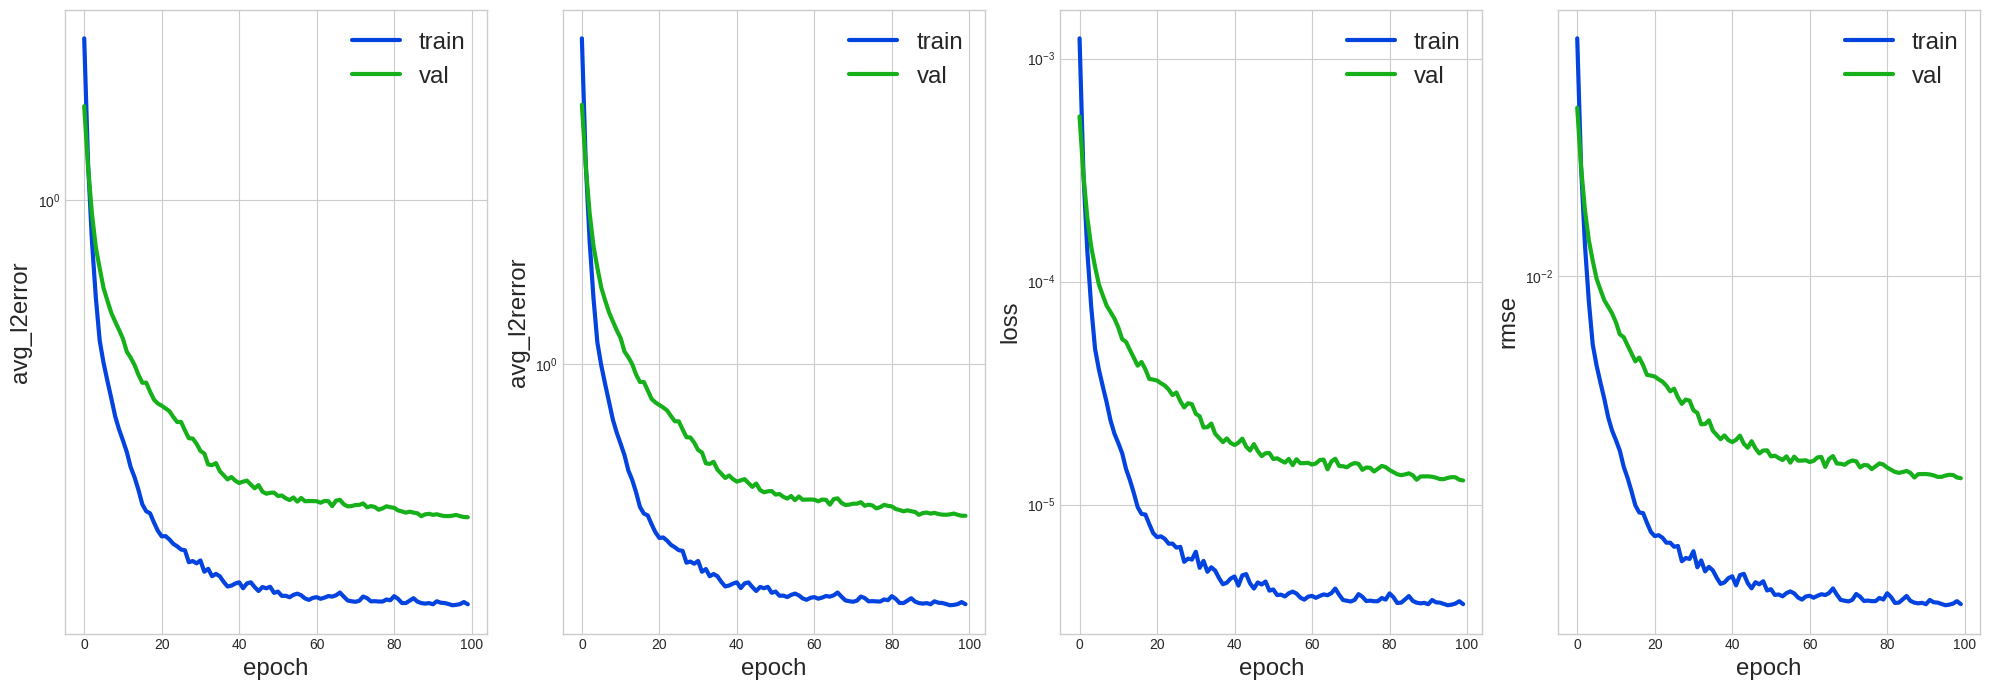

In [ ]:
metrics = chonknoris.parse_metrics("%s/%s/csv/metrics.csv"%(save_dir,name))
fig,ax = chonknoris.plot_metrics(metrics,linewidth=LWTHICK,color_train=COLORS[0],color_val=COLORS[1],s0=0)
fig.tight_layout()
metrics.iloc[::max(1,len(metrics)//8)]

In [ ]:
lnn = lnn.to(DEVICE) 
with torch.no_grad(), torch.inference_mode():
    outputs_v_hat_sgp_raw_mlp = lnn(inputs_v.to(DEVICE))
print("l2 relative error: %.2e"%(torch.linalg.norm(outputs_v_hat_sgp_raw_mlp-outputs_v.to(DEVICE),dim=-1)/torch.linalg.norm(outputs_v.to(DEVICE),dim=-1)).mean())

l2 relative error: 4.60e-01


## GPR

In [107]:
import gc
gc.collect()
torch.cuda.empty_cache()
sgp = fastgps.StandardGP(
    #1+Nx*Nx+Ns*Nt*Nx,
    Nx*Nx+Ns*Nt*Nx,
    data={"x":inputs_t.to(DEVICE),"y":outputs_t.T.to(DEVICE)},
    shape_batch=[Nx*Nx*(1+Nx*Nx)//2],
    device=DEVICE,
    #lengthscales=np.sqrt(1+Nx*Nx+Ns*Nt*Nx),
    lengthscales=np.sqrt(Nx*Nx+Ns*Nt*Nx),
    #shape_lengthscales=[1],
    #shape_lengthscales=[1+Nx*Nx+Ns*Nt*Nx],
    shape_lengthscales=[Nx*Nx+Ns*Nt*Nx],
    noise = 1e-8,
    requires_grad_noise=True,
    compile_dist_func=True,
    kernel_class="matern52",
    # tfs_scale = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_lengthscales = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_noise = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_scale = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_lengthscales = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_noise = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_scale = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_lengthscales = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_noise = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
)
for pname,pval in sgp.named_parameters():
    print("%s.shape = %s"%(pname,str(tuple(pval.shape))))
print()
fit_data_sgp = sgp.fit(
    loss_metric = "CV",
    #cv_weights = 1/torch.linalg.norm(outputs_t.to(DEVICE),dim=1),
    #cv_weights = torch.log10(1/relaxations_t[updated_t]).to(DEVICE)**4,
    # cv_weights = torch.log10(relaxations_t[updated_t].to(DEVICE))/torch.linalg.norm(outputs_t.to(DEVICE),dim=1),
    iterations = 25,
    verbose = 1,
    store_hists = True,
    stop_crit_wait_iterations = 100,
    stop_crit_improvement_threshold = 1e-1,
    #lr = 1e0,
    #optimizer=torch.optim.Rprop(sgp.parameters(),lr=1e0),#,etas=(0.5,1.2),step_sizes=(0,10)),
    #optimizer=torch.optim.Adam(sgp.parameters(),lr=1e0,amsgrad=True),#,lr=5e-2),
    )

raw_scale.shape = (1,)
raw_lengthscales.shape = (1800,)
raw_noise.shape = (1,)
raw_factor_task_kernel.shape = (1, 0)
raw_noise_task_kernel.shape = (1,)

     iter of 2.5e+01 | loss       | term1      | term2     
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 3.71e+10   | nan        | nan       
            1.00e+00 | 3.29e+10   | nan        | nan       
            2.00e+00 | 2.93e+10   | nan        | nan       
            3.00e+00 | 2.61e+10   | nan        | nan       
            4.00e+00 | 2.32e+10   | nan        | nan       
            5.00e+00 | 2.02e+10   | nan        | nan       
            6.00e+00 | 1.71e+10   | nan        | nan       
            7.00e+00 | 1.40e+10   | nan        | nan       
            8.00e+00 | 1.13e+10   | nan        | nan       
            9.00e+00 | 9.31e+09   | nan        | nan       
            1.00e+01 | 7.46e+09   | nan        | nan       
            1.10e+01 | 5.96e+09   | nan        | nan       
       

In [108]:
outputs_v_hat_sgp = sgp.post_mean(inputs_v.to(DEVICE)).T
l2rerrors_v = torch.linalg.norm(outputs_v_hat_sgp-outputs_v.to(DEVICE),dim=-1)/torch.linalg.norm(outputs_v.to(DEVICE),dim=-1)
l2rerrors_v_gamma = torch.linalg.norm(outputs_v_hat_sgp[:,:Nx**2]-outputs_v[:,:Nx**2].to(DEVICE),dim=-1)/torch.linalg.norm(outputs_v[:,:Nx**2].to(DEVICE),dim=-1)
l2rerrors_v_C = torch.linalg.norm(outputs_v_hat_sgp[:,Nx**2:]-outputs_v[:,Nx**2:].to(DEVICE),dim=-1)/torch.linalg.norm(outputs_v[:,Nx**2:].to(DEVICE),dim=-1)
print("l2 relative error      : %.2e"%torch.mean(l2rerrors_v))
print("l2 relative error gamma: %.2e"%torch.mean(l2rerrors_v_gamma))
print("l2 relative error C    : %.2e"%torch.mean(l2rerrors_v_C))

l2 relative error      : 8.05e-01
l2 relative error gamma: 8.00e-01
l2 relative error C    : 8.11e-01


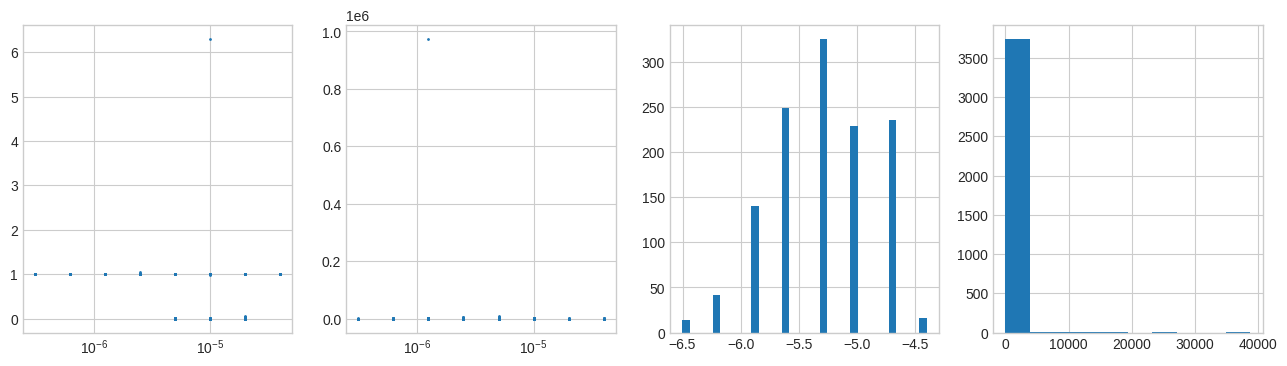

In [109]:
fig,ax = pyplot.subplots(nrows=1,ncols=4,figsize=(16,4))
ax[0].scatter(relaxations_v[updated_v].cpu(),l2rerrors_v.cpu(),s=1)
ax[0].set_xscale("log",base=10)
ax[1].scatter(relaxations_v[updated_v].cpu(),torch.linalg.norm(outputs_v.to(DEVICE),dim=1).cpu(),s=1)
ax[1].set_xscale("log",base=10)
ax[2].hist(torch.log10(relaxations_v[updated_v].cpu()),bins=32);
ax[3].hist(torch.linalg.norm(outputs_t.to(DEVICE),dim=1).cpu());

dict_keys(['iterations', 'loss_hist', 'scale_hist', 'lengthscales_hist', 'noise_hist', 'task_kernel_hist'])


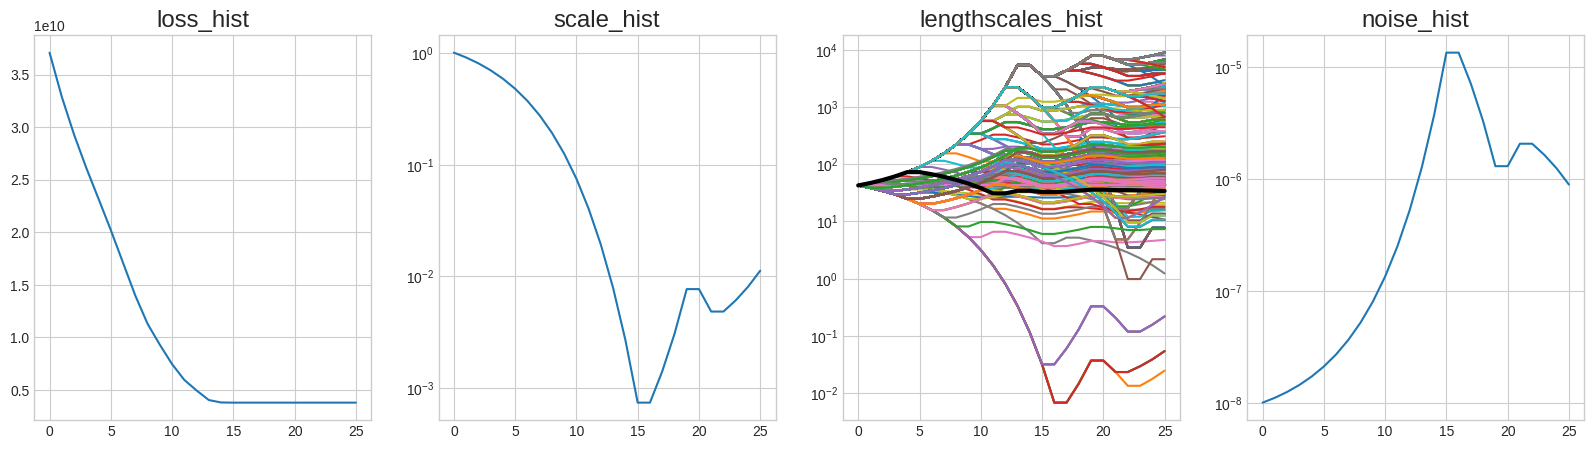

In [110]:
print(fit_data_sgp.keys())
keys_to_plot_log10ed = [
    ('loss_hist',False),
    ('scale_hist',True),
    ('lengthscales_hist',True),
    ('noise_hist',True)]
ncols = len(keys_to_plot_log10ed)
fig,ax = pyplot.subplots(nrows=1,ncols=ncols,figsize=(5*ncols,5))
for i,(key,log10ed) in enumerate(keys_to_plot_log10ed):
    ax[i].plot(torch.arange(fit_data_sgp[key].size(0)),fit_data_sgp[key])
    ax[i].set_title(key,fontsize="xx-large")
    if log10ed: ax[i].set_yscale('log',base=10)
ax[2].plot(torch.arange(fit_data_sgp["lengthscales_hist"].size(0)),fit_data_sgp["lengthscales_hist"][:,0],color="k",linewidth=3);

## Inference

In [111]:
#lmodel = lnn.to(DEVICE)
lmodel = lambda x: sgp.post_mean(x).T
def predict(relaxations, v, w, JtF):
    assert relaxations.ndim==1 and v.ndim==2 and relaxations.size(0)==v.size(0)==w.size(0)
    inputs_raw = torch.cat([v,w.flatten(start_dim=1)],dim=-1)
    inputs = (inputs_raw-inputs_raw_t_mean)/inputs_raw_t_std
    C = torch.zeros((v.size(0),Nx**2,Nx**2),device=v.device)
    with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var():
        out_raw_flat = lmodel(inputs)
    out_flat = out_raw_flat*outputs_raw_t_std+outputs_raw_t_mean
    log10Gamma_flat,C_flat = out_flat[:,:Nx**2],out_flat[:,Nx**2:]
    C[:,lt1i0,lt1i1] = C_flat
    C = C-C.transpose(dim0=-2,dim1=-1)
    Q = torch.linalg.solve(_eyeNx2+C,_eyeNx2-C,left=False)
    D = 10**log10Gamma_flat+relaxations[:,None]
    #L[:,_Nxr2,_Nxr2] = torch.exp(L[:,_Nxr2,_Nxr2])
    success = torch.ones(v.size(0),dtype=bool,device=v.device)
    # delta_try = torch.einsum("rji,rj->ri",L,torch.einsum("rij,rj->ri",L,JtF))
    #delta_try = torch.cholesky_solve(JtF[success,:,None],L[success],upper=False)[...,0]
    delta_try = torch.einsum("rij,rj->ri",Q,torch.einsum("rji,rj->ri",Q,JtF)/D)
    return delta_try,success
R_infer = 10
num_newton_iter_infer = 50
vref = data["velocity"][data["vidxs"]][:R_infer].to(DEVICE)
w = data["wavefield"][data["vidxs"]][:R_infer].to(DEVICE)
#v0 = data["vs"][data["vidxs"]][:R_infer,0].to(DEVICE)
# v0 = data["vs"][data["vidxs"]][:R_infer,10].to(DEVICE)
v0 = outputs_v_hat_sgp_ig[:R_infer].reshape((R_infer,Nx,Nx))
_,data_infer = fwi_gn_solver(p,w,v0,num_newton_iter=num_newton_iter_infer,vref=vref,use_pca=False,predict=predict,print_rmse_flow=False,
                             relaxation=1e-5,
                             lr=1,
                             wiggle_factors_relaxation=(1/2,2),
                             wiggle_factors_lr=(1/2,2),
                             range_relaxations=(0,1e-3),
                             range_lrs = (0,100))
#_,data_infer = fwi_gn_solver(p,w,v0,num_newton_iter=num_newton_iter_infer,relaxation=4.8e-8,lr=1,vref=vref,use_pca=False,predict=predict,print_rmse_flow=False,wiggle_factor_relaxation=2,wiggle_factor_lr=2)


    iter of 50     | time      | RMSE                                                             | L2 relative error                                   | relaxations                                         | lrs                                                 |
                   |           | 5%           median       mean         95%          finite %     | 5%           median       mean         95%          | 5%           median       mean         95%          | 5%           median       mean         95%          |
    -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0              | 8.86e+00  | 8.79e-01     1.48e+00     1.47e+00     2.18e+00     100.0        | 1.18e-02     1.66e-02     2.07e-02     3.66e-02     | 1.00e-05     1.00e-05     1.00e-05     1.00e-05     | 1.00e+

/home/aleksei.sorokin/DeepNewtonOperator/chonknoris/plots.py:99: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,j].legend(frameon=False,fontsize="xx-large")


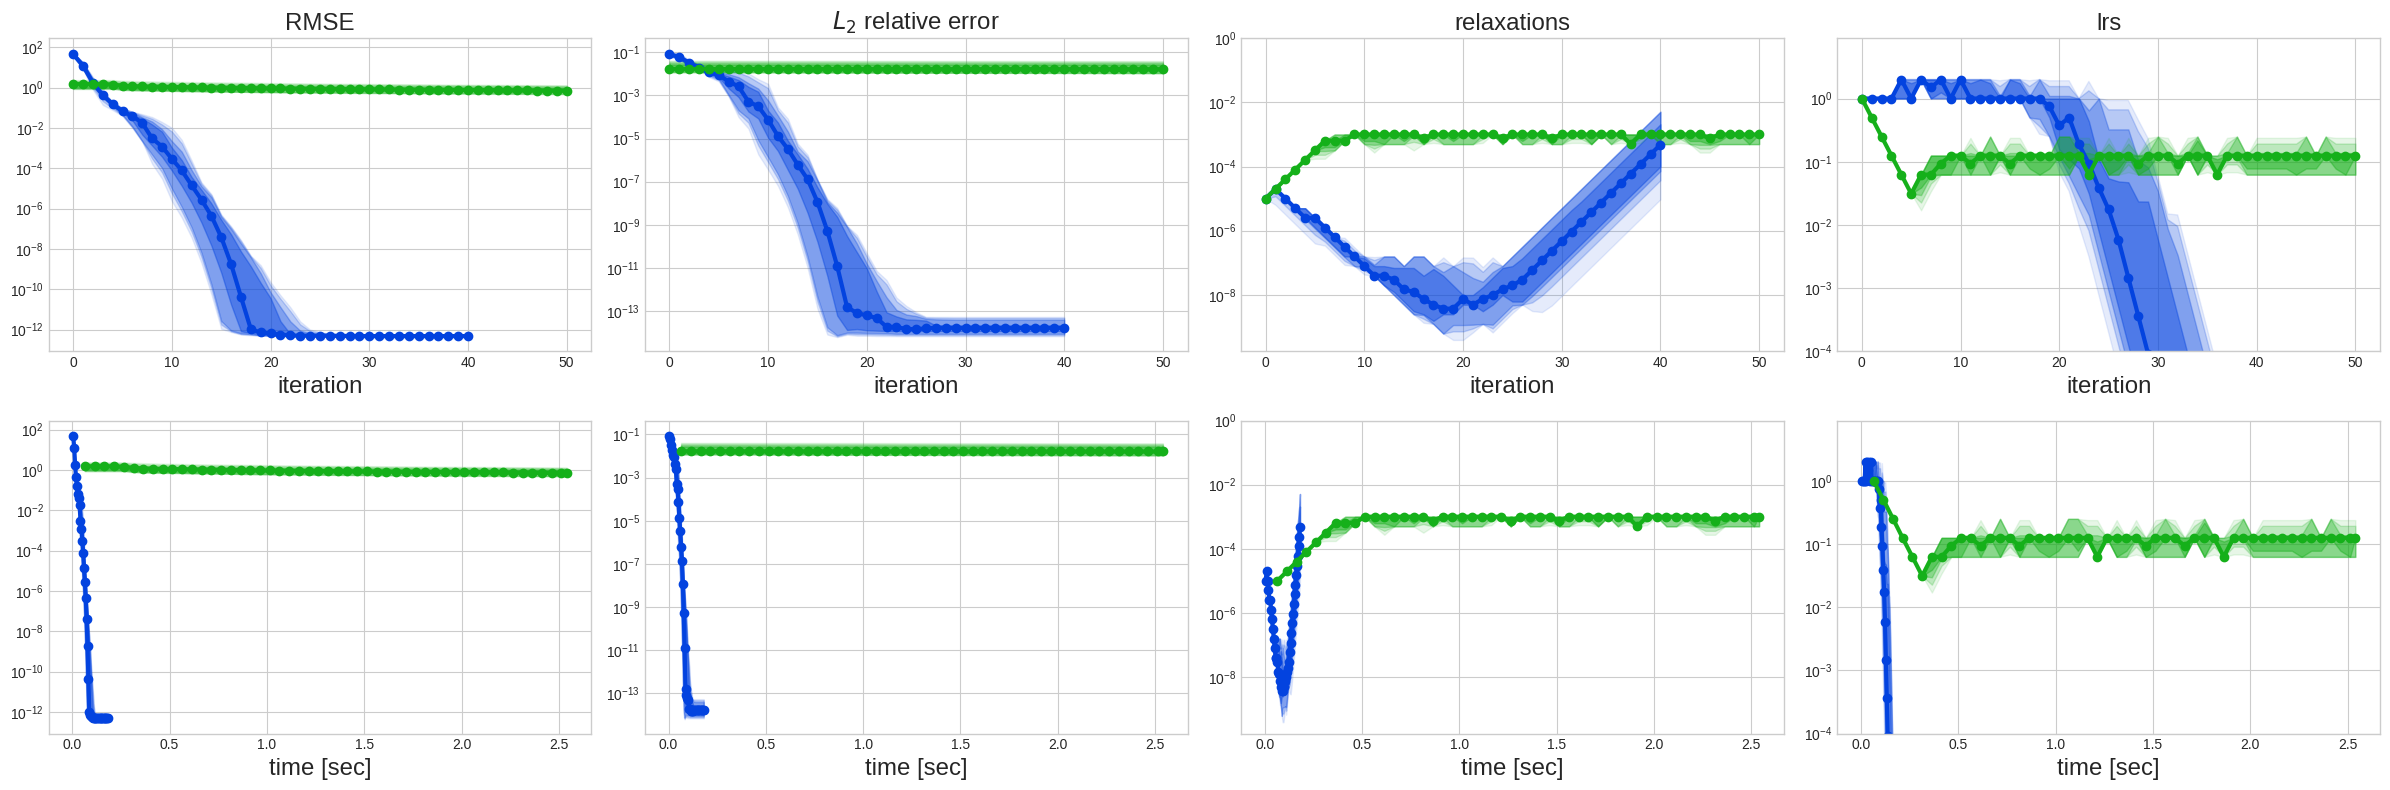

In [51]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [
                (None,data["rmses"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                (None,data_infer["rmses"],None)
            ],
            [
                (None,data["l2rerrors"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                (None,data_infer["l2rerrors"],None)],
            [
                (None,data["relaxations"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                (None,data_infer["relaxations"],None)],
            [
                (None,data["lrs"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                (None,data_infer["lrs"],None)],

        ],
        [
            [
                (data["times"][:num_newton_iter_infer].cumsum(0),data["rmses"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["rmses"],None)],
            [
                (data["times"][:num_newton_iter_infer].cumsum(0),data["l2rerrors"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["l2rerrors"],None)],
            [
                (data["times"][:num_newton_iter_infer].cumsum(0),data["relaxations"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["relaxations"],None)],
            [
                (data["times"][:num_newton_iter_infer].cumsum(0),data["lrs"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["lrs"],None)],

        ],
    ],
    sharex = False,
    titles = [["RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None]],
    xlabels = [["iteration"],["time [sec]"]],
    xlogscale = False,
    colors = COLORS,
    ylogscale = True,
    fsx=4,fsy=6)
for i in range(2):
    ax[i,2].set_ylim([ax[i,2].get_ylim()[0],1])
    ax[i,3].set_ylim([1e-4,ax[i,3].get_ylim()[1]])
fig.tight_layout()

tensor([0.0451, 0.0480, 0.0406, 0.0385, 0.0345])
tensor([1.8215e-07, 1.6735e-12, 1.0010e-12, 2.2384e-07, 3.1155e-09])


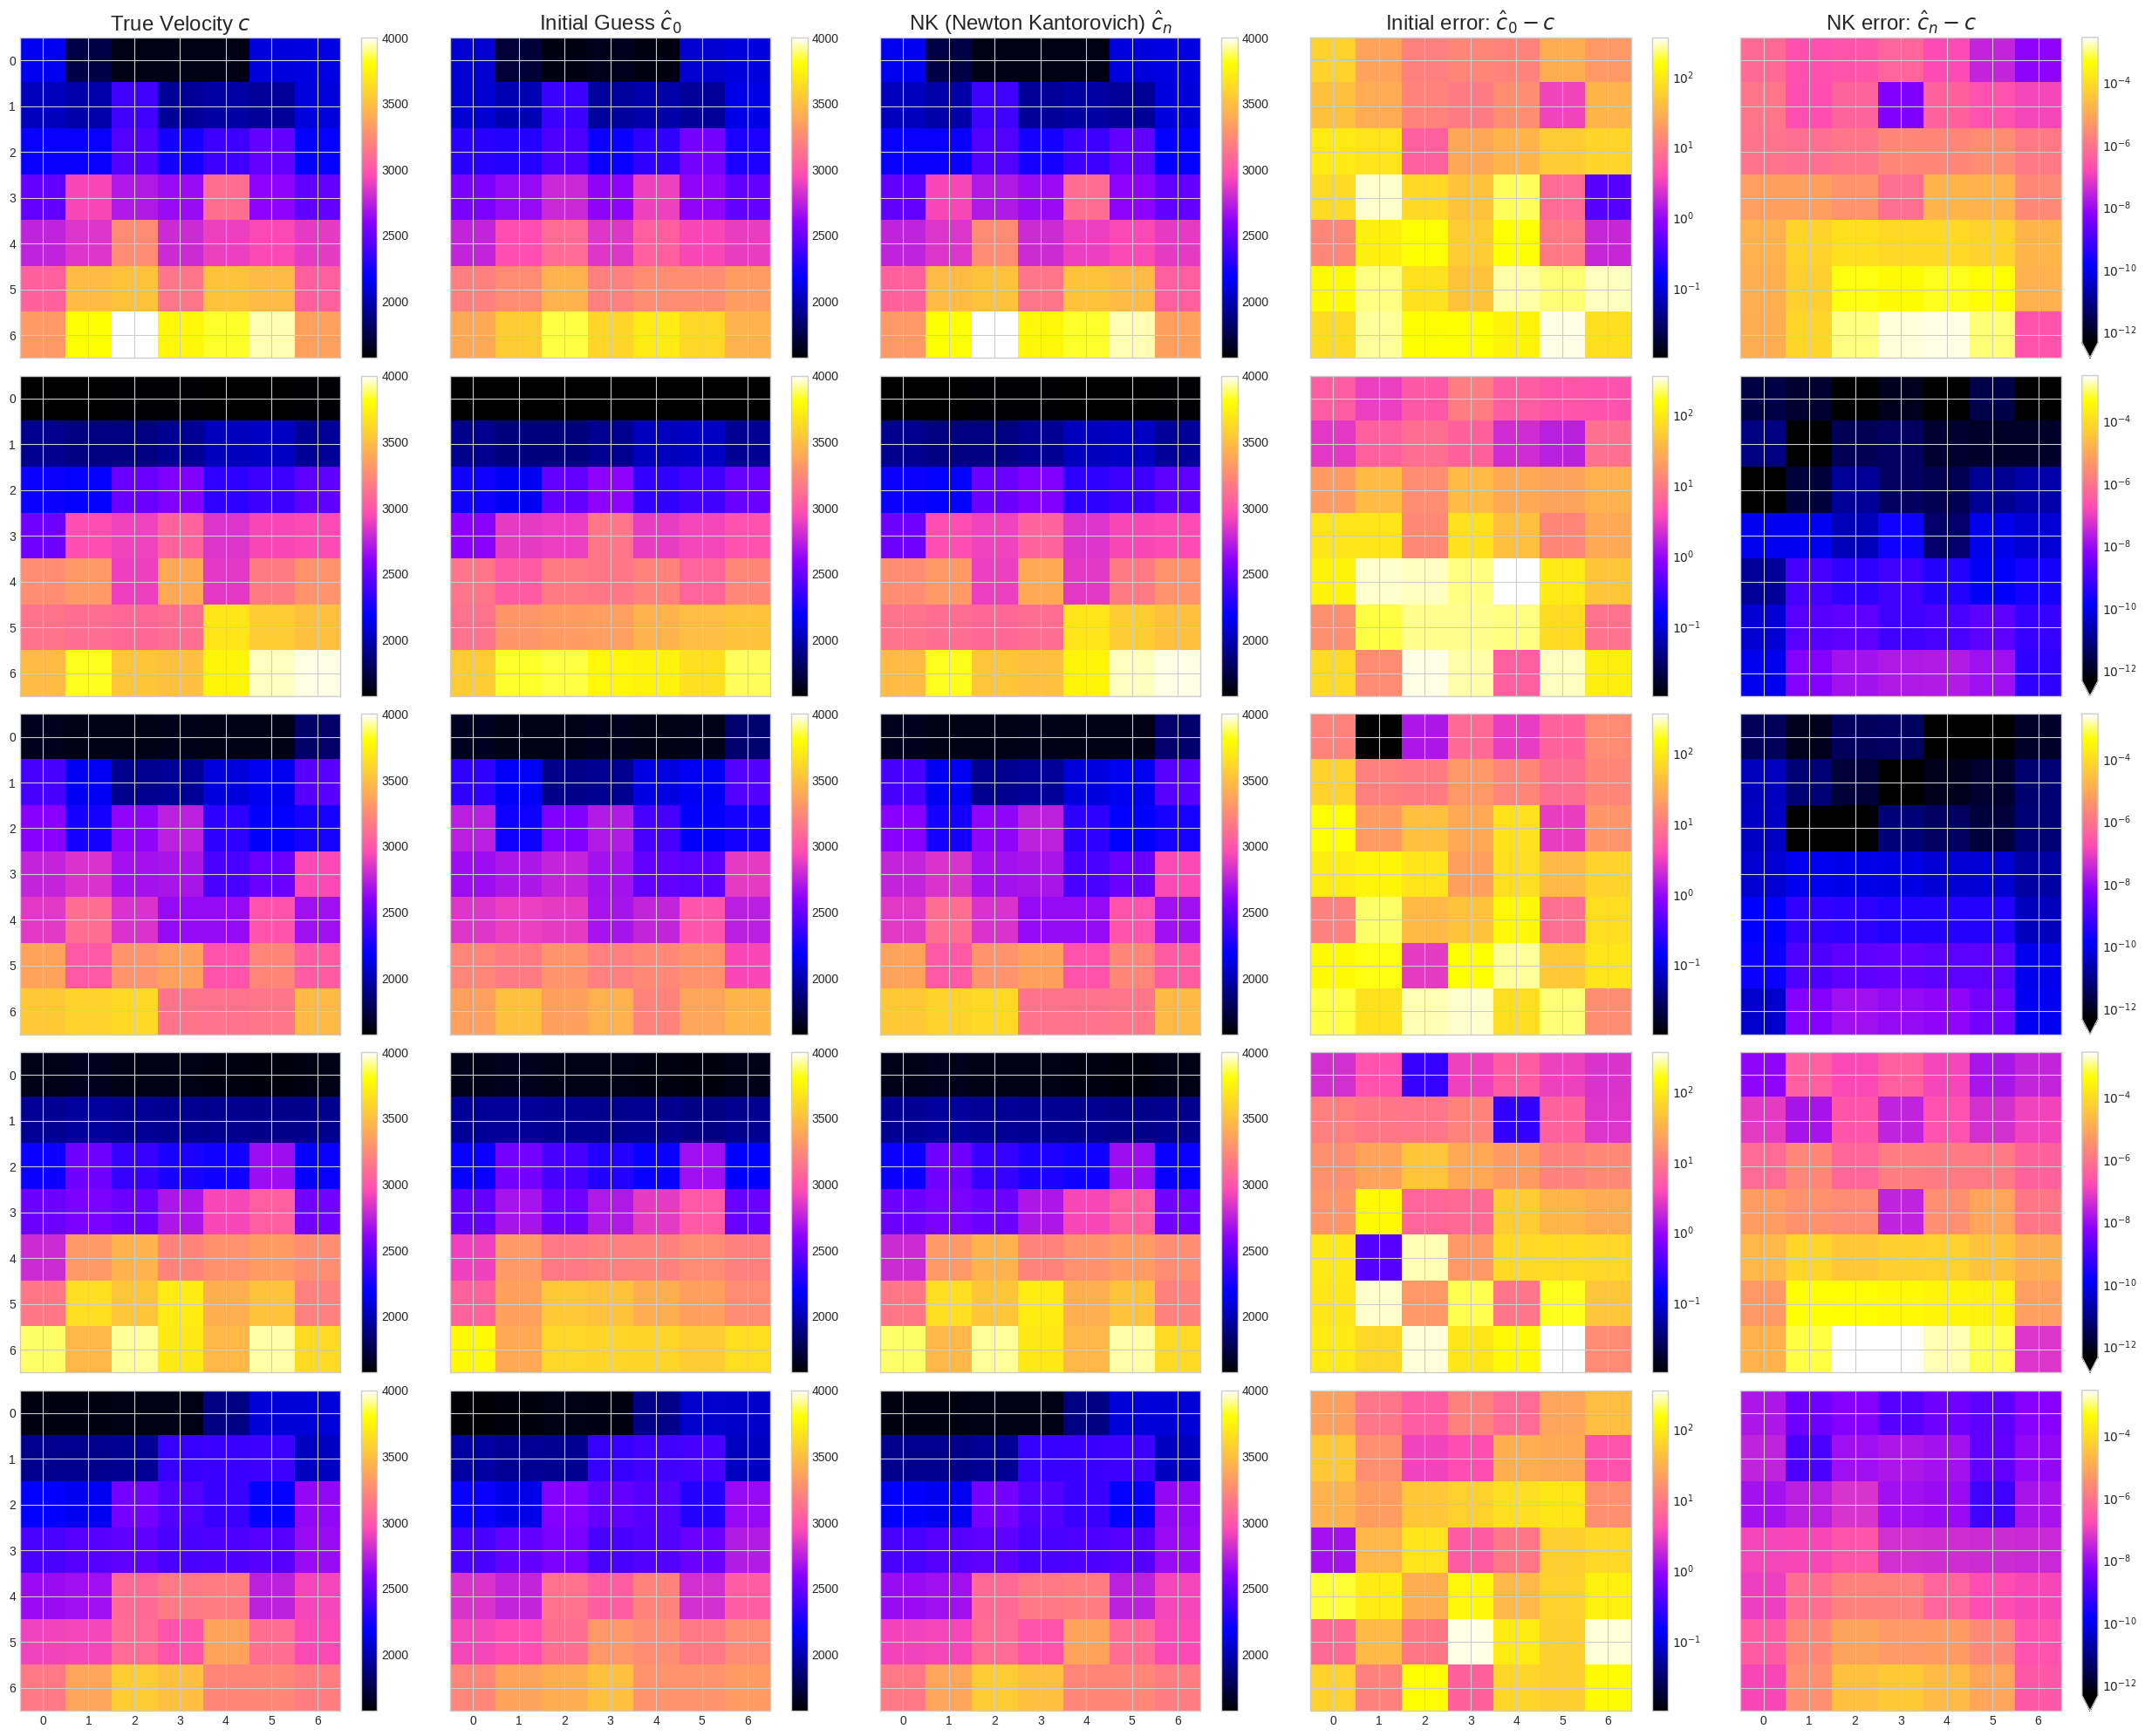

In [ ]:
Rplt = 5
print(data_infer["l2rerrors"][:Rplt,0])
print(data_infer["l2rerrors"][:Rplt,-1])
plot_nk_velocities(vref.cpu()[:Rplt],data_infer["vs"][:Rplt,0].cpu(),data_infer["vs"][:Rplt,-1].cpu());